# Loan Portfolio Risk & Acquisition Analytics

**End-to-End Data Analytics Project | Python • SQL • Power BI • DAX**

## Project Overview
This project analyzes a large Lending Club loan portfolio to evaluate portfolio exposure, financial performance, recoveries, acquisition quality, and borrower credit risk. The workflow combines Python-based exploratory analysis, SQL analysis using DuckDB in Google Colab, and a three-page Power BI dashboard for decision-oriented reporting.

## Business Problem
Lending portfolios can generate substantial funding volume while still producing weak financial outcomes when credit losses, borrower risk, loan structure, and acquisition quality are not properly evaluated. This project investigates the factors associated with charge-offs and weaker cash performance and translates the findings into portfolio and acquisition insights.

## Objectives
- Analyze portfolio size, funded exposure, and loan-status composition.
- Evaluate charge-off patterns across loan grades and borrower-risk segments.
- Compare financial performance across loan grades and terms.
- Analyze recoveries, payments, principal, interest, and net cash outcomes.
- Examine acquisition categories and funded exposure.
- Assess borrower risk using FICO, DTI, delinquency, bankruptcy, utilization, and recent credit inquiry indicators.
- Prepare analytical outputs for an executive Power BI dashboard.

## Dataset
- **Source:** Lending Club loan portfolio dataset
- **Period:** 2015–2018
- **Records:** approximately 1.79 million loans
- **Fields:** 56

## Tools & Technologies
- **Python:** pandas, NumPy, matplotlib/seaborn where used in the notebook
- **SQL:** DuckDB SQL executed within Google Colab
- **Power BI:** dashboarding and business visualization
- **DAX:** portfolio, performance, recovery, and risk measures

## Analytical Workflow
```text
Loan Portfolio Data
        ↓
Data Preparation & Profiling
        ↓
Python EDA & Financial Analysis
        ↓
DuckDB SQL Analysis & Validation
        ↓
Power BI Data Model + DAX
        ↓
3-Page Executive Dashboard
        ↓
Key Insights & Business Recommendations
```

> **Notebook note:** This notebook preserves the original analysis and results. The sections below contain the detailed exploratory, financial, risk, SQL, and dashboard-preparation work used in the project.


# Part I — Python Data Analysis

The following sections contain the original Python-based data loading, preparation, exploratory analysis, financial analysis, risk segmentation, and visualization work.


In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

file_path = "/content/Loan_Portfolio_Cleaned_2015_2018.csv.gz"

df = pd.read_csv(
    file_path,
    compression="gzip",
    low_memory=False
)

print("Dataset loaded successfully!")
print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 1,794,323
Columns: 56


In [ ]:
# Portfolio Overview KPIs

total_loans = len(df)

total_loan_amount = df["loan_amnt"].sum()
total_funded_amount = df["funded_amnt"].sum()

average_loan_amount = df["loan_amnt"].mean()
median_loan_amount = df["loan_amnt"].median()

average_interest_rate = df["int_rate"].mean()

print("===== PORTFOLIO OVERVIEW =====")
print(f"Total Loans: {total_loans:,}")
print(f"Total Loan Amount: ${total_loan_amount:,.2f}")
print(f"Total Funded Amount: ${total_funded_amount:,.2f}")
print(f"Average Loan Amount: ${average_loan_amount:,.2f}")
print(f"Median Loan Amount: ${median_loan_amount:,.2f}")
print(f"Average Interest Rate: {average_interest_rate:.2f}%")

===== PORTFOLIO OVERVIEW =====
Total Loans: 1,794,323
Total Loan Amount: $27,339,398,100.00
Total Funded Amount: $27,339,370,100.00
Average Loan Amount: $15,236.61
Median Loan Amount: $13,000.00
Average Interest Rate: 12.90%


### Portfolio Overview — Initial Insights

- The dataset contains approximately 1.79 million loans representing $27.34 billion in total loan exposure.
- The average loan size is $15,236.61, while the median is $13,000, indicating a right-skewed loan-size distribution.
- The average interest rate across the portfolio is 12.90%.
- Total funded amount is almost identical to total loan amount, indicating minimal difference between requested and funded amounts in the selected dataset.

In [ ]:
# Loan Term Distribution

term_distribution = (
    df["term"]
    .value_counts()
    .reset_index()
)

term_distribution.columns = ["Loan Term", "Number of Loans"]

term_distribution["Percentage"] = (
    term_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

term_distribution

,Loan Term,Number of Loans,Percentage
0,36 months,1271758,70.88
1,60 months,522565,29.12


In [ ]:
# Loan Grade Distribution

grade_distribution = (
    df["grade"]
    .value_counts()
    .sort_index()
    .reset_index()
)

grade_distribution.columns = ["Grade", "Number of Loans"]

grade_distribution["Percentage"] = (
    grade_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

grade_distribution

,Grade,Number of Loans,Percentage
0,A,358156,19.96
1,B,526610,29.35
2,C,524739,29.24
3,D,247524,13.79
4,E,99880,5.57
5,F,28568,1.59
6,G,8846,0.49


### Loan Structure & Grade Insights

- 36-month loans account for 70.88% of the portfolio, while 60-month loans account for 29.12%.
- B and C grade loans represent 58.59% of all loans, making them the dominant risk segments.
- Approximately 78.55% of loans fall within grades A–C, while 21.45% fall within grades D–G.
- Loan grade provides an initial view of portfolio risk, but acquisition attractiveness will require combining grade with credit quality, loan performance, and recovery metrics.

In [ ]:
purpose_distribution = (
    df["purpose"]
    .value_counts()
    .reset_index()
)

purpose_distribution.columns = ["Loan Purpose", "Number of Loans"]

purpose_distribution["Percentage"] = (
    purpose_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

purpose_distribution

,Loan Purpose,Number of Loans,Percentage
0,debt_consolidation,1003644,55.93
1,credit_card,412802,23.01
2,home_improvement,123916,6.91
3,other,115748,6.45
4,major_purchase,40617,2.26
5,medical,22885,1.28
6,car,18615,1.04
7,small_business,17675,0.99
8,vacation,13038,0.73
9,moving,12408,0.69


### Loan Purpose Insights

- Debt consolidation is the largest loan purpose, accounting for 55.93% of all loans.
- Credit card loans account for another 23.01%.
- Together, debt consolidation and credit card loans represent 78.94% of the portfolio.
- The high concentration in debt-related purposes makes borrower leverage and credit-quality variables such as DTI, revolving utilization, FICO score, and delinquency history important for subsequent risk analysis.
- Purpose concentration alone does not establish default risk; performance analysis is required to determine whether these segments actually perform differently.

In [ ]:
# Borrower Income Analysis

income_summary = df["annual_inc"].describe()

income_summary

,annual_inc
count,1.794323e+06
mean,7.921845e+04
std,1.233243e+05
min,0.000000e+00
25%,4.700000e+04
50%,6.500000e+04
75%,9.500000e+04
max,1.100000e+08


In [ ]:
# Key Income KPIs

print("===== BORROWER INCOME PROFILE =====")
print(f"Average Annual Income: ${df['annual_inc'].mean():,.2f}")
print(f"Median Annual Income: ${df['annual_inc'].median():,.2f}")
print(f"Minimum Annual Income: ${df['annual_inc'].min():,.2f}")
print(f"Maximum Annual Income: ${df['annual_inc'].max():,.2f}")

===== BORROWER INCOME PROFILE =====
Average Annual Income: $79,218.45
Median Annual Income: $65,000.00
Minimum Annual Income: $0.00
Maximum Annual Income: $110,000,000.00


### Borrower Income Insights

- The average annual borrower income is $79,218.45, while the median is $65,000.
- The difference between mean and median indicates a right-skewed income distribution caused by high-income observations.
- The maximum reported income is $110 million, representing an extreme value that should not be used as a proxy for the typical borrower.
- Median income and income bands will be more useful than the mean for subsequent borrower-risk segmentation.
- Borrowers reporting zero income will be investigated before making any exclusion or treatment decision.

In [ ]:
# Employment Length Distribution

employment_distribution = (
    df["emp_length"]
    .value_counts(dropna=False)
    .reset_index()
)

employment_distribution.columns = [
    "Employment Length",
    "Number of Loans"
]

employment_distribution["Percentage"] = (
    employment_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

employment_distribution

,Employment Length,Number of Loans,Percentage
0,10+ years,597932,33.32
1,2 years,162301,9.05
2,< 1 year,153720,8.57
3,3 years,144155,8.03
4,NaN,125889,7.02
5,1 year,118781,6.62
6,5 years,108919,6.07
7,4 years,108581,6.05
8,6 years,76514,4.26
9,8 years,69517,3.87


### Employment Stability Insights

- Borrowers with 10+ years of employment represent 33.32% of the portfolio, making this the largest employment segment.
- Borrowers with less than one year of employment account for 8.57% of loans.
- Employment information is missing for 7.02% of records and will be retained rather than automatically removed.
- Employment length may provide an indicator of borrower stability, but its relationship with loan performance will be tested through subsequent risk analysis.

In [ ]:
# Home Ownership Distribution

home_ownership_distribution = (
    df["home_ownership"]
    .value_counts(dropna=False)
    .reset_index()
)

home_ownership_distribution.columns = [
    "Home Ownership",
    "Number of Loans"
]

home_ownership_distribution["Percentage"] = (
    home_ownership_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

home_ownership_distribution

,Home Ownership,Number of Loans,Percentage
0,MORTGAGE,875542,48.80
1,RENT,706437,39.37
2,OWN,211345,11.78
3,ANY,995,0.06
4,NONE,4,0.00


### Home Ownership Insights

- Mortgage borrowers represent 48.80% of the portfolio, making them the largest home-ownership segment.
- Renters account for 39.37% of borrowers.
- Mortgage and rental borrowers together represent 88.17% of the portfolio.
- Borrowers reporting outright home ownership account for 11.78%.
- Home ownership will be used as a segmentation variable, but its relationship with loan performance will be tested rather than assumed.

In [ ]:
# DTI Summary

dti_summary = df["dti"].describe()

dti_summary

,dti
count,1.790049e+06
mean,1.892191e+01
std,9.607161e+00
min,0.000000e+00
25%,1.204000e+01
50%,1.810000e+01
75%,2.495000e+01
max,1.000000e+02


In [ ]:
# Key DTI KPIs

print("===== BORROWER DTI PROFILE =====")
print(f"Average DTI: {df['dti'].mean():.2f}%")
print(f"Median DTI: {df['dti'].median():.2f}%")
print(f"Minimum DTI: {df['dti'].min():.2f}%")
print(f"Maximum DTI: {df['dti'].max():.2f}%")

===== BORROWER DTI PROFILE =====
Average DTI: 18.92%
Median DTI: 18.10%
Minimum DTI: 0.00%
Maximum DTI: 100.00%


### Debt-to-Income (DTI) Insights

- The average borrower DTI is 18.92%, while the median is 18.10%.
- The middle 50% of borrowers have DTI between 12.04% and 24.95%.
- DTI has approximately 0.24% missing values, which is low enough to retain without removing records.
- The cleaned dataset contains values up to 100% DTI. Extremely high DTI values will be treated as high-risk observations rather than automatically removed.
- DTI will be used as a core variable in subsequent risk segmentation and loan-performance analysis.

In [ ]:
# FICO Score Analysis

df["fico_score"] = (
    df["fico_range_low"] + df["fico_range_high"]
) / 2

fico_summary = df["fico_score"].describe()

fico_summary

,fico_score
count,1.794323e+06
mean,7.012318e+02
std,3.353887e+01
min,6.620000e+02
25%,6.770000e+02
50%,6.920000e+02
75%,7.170000e+02
max,8.475000e+02


In [ ]:
print("===== BORROWER FICO PROFILE =====")
print(f"Average FICO Score: {df['fico_score'].mean():.2f}")
print(f"Median FICO Score: {df['fico_score'].median():.2f}")
print(f"Minimum FICO Score: {df['fico_score'].min():.0f}")
print(f"Maximum FICO Score: {df['fico_score'].max():.0f}")

===== BORROWER FICO PROFILE =====
Average FICO Score: 701.23
Median FICO Score: 692.00
Minimum FICO Score: 662
Maximum FICO Score: 848


### Borrower FICO Insights

- The average borrower FICO score is 701.23, while the median is 692.
- The middle 50% of borrowers have FICO scores between 677 and 717.
- FICO scores range from 662 to 848 in the portfolio.
- The difference between mean and median indicates some higher-score observations influence the average.
- FICO score will be used as a core credit-quality variable in subsequent risk and loan-performance analysis.
- The relationship between FICO score and default/charge-off performance will be tested rather than assumed.

In [ ]:
# State-wise Loan Distribution

state_distribution = (
    df["addr_state"]
    .value_counts()
    .reset_index()
)

state_distribution.columns = [
    "State",
    "Number of Loans"
]

state_distribution["Percentage"] = (
    state_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

state_distribution.head(15)

,State,Number of Loans,Percentage
0,CA,243073,13.55
1,TX,149895,8.35
2,NY,146144,8.14
3,FL,130348,7.26
4,IL,72560,4.04
5,NJ,65069,3.63
6,PA,60515,3.37
7,OH,59894,3.34
8,GA,59219,3.30
9,NC,50044,2.79


### Geographic Distribution Insights

- California is the largest geographic segment, accounting for 13.55% of all loans.
- Texas, New York, and Florida follow with 8.35%, 8.14%, and 7.26%, respectively.
- The four largest states together account for 37.30% of the portfolio.
- This indicates meaningful geographic concentration that should be considered when evaluating portfolio risk.
- Geographic concentration will be evaluated against actual loan performance before being classified as a risk factor.

In [ ]:
# Interest Rate by Loan Grade

grade_interest = (
    df.groupby("grade")
      .agg(
          Number_of_Loans=("id", "count"),
          Average_Interest_Rate=("int_rate", "mean"),
          Average_Loan_Amount=("loan_amnt", "mean")
      )
      .reset_index()
      .sort_values("grade")
)

grade_interest["Average_Interest_Rate"] = (
    grade_interest["Average_Interest_Rate"].round(2)
)

grade_interest["Average_Loan_Amount"] = (
    grade_interest["Average_Loan_Amount"].round(2)
)

grade_interest

,grade,Number_of_Loans,Average_Interest_Rate,Average_Loan_Amount
0,A,358156,6.99,14855.01
1,B,526610,10.46,14447.29
2,C,524739,14.03,15238.96
3,D,247524,18.33,15913.82
4,E,99880,22.31,17423.93
5,F,28568,26.34,19445.12
6,G,8846,29.29,20298.82


### Risk Grade & Pricing Insights

- Interest rates increase consistently from Grade A (6.99%) to Grade G (29.29%).
- The relationship indicates that higher-risk loan grades are associated with substantially higher borrowing costs.
- Average loan size also generally increases across higher-risk grades, from $14,855 for Grade A to $20,299 for Grade G.
- Higher-risk segments therefore need to be evaluated using both risk indicators and financial exposure rather than loan count alone.
- The relationship between grade and actual loan performance will be tested next.

In [ ]:
# Overall Loan Performance Distribution

loan_status_distribution = (
    df["loan_status"]
    .value_counts()
    .reset_index()
)

loan_status_distribution.columns = [
    "Loan Status",
    "Number of Loans"
]

loan_status_distribution["Percentage"] = (
    loan_status_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

loan_status_distribution

,Loan Status,Number of Loans,Percentage
0,Current,866392,48.29
1,Fully Paid,702191,39.13
2,Charged Off,192060,10.70
3,Late (31-120 days),21130,1.18
4,In Grace Period,8235,0.46
5,Late (16-30 days),4276,0.24
6,Default,39,0.00


### Overall Loan Performance Insights

- Current loans represent 48.29% of the portfolio, while Fully Paid loans represent 39.13%.
- Charged Off loans account for 10.70% of all loans, representing 192,060 loans.
- Loans currently in late-payment categories represent an additional 1.42% of the portfolio.
- Current loans have not yet reached a final outcome, so they should not automatically be classified as successful or unsuccessful.
- For subsequent analysis, loan performance will be segmented into Performing, At Risk, and Distressed categories.
- Final performance and acquisition-risk metrics will distinguish between active loans and loans with completed outcomes.

In [ ]:
# Loan Performance by Risk Grade

grade_status = pd.crosstab(
    df["grade"],
    df["loan_status"],
    normalize="index"
) * 100

grade_status.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
grade,,,,,,,
A,2.80,54.53,0.00,42.03,0.18,0.09,0.37
B,7.11,49.55,0.00,41.91,0.33,0.19,0.90
C,12.05,47.98,0.00,37.70,0.56,0.28,1.42
D,17.32,45.11,0.01,34.57,0.74,0.38,1.88
E,25.28,36.38,0.01,35.10,0.75,0.39,2.09
F,34.75,28.10,0.00,33.78,0.79,0.42,2.15
G,37.45,26.25,0.00,32.22,1.07,0.41,2.60


### Risk Grade vs Loan Performance Insights

- Charge-off proportions increase consistently as loan grade deteriorates, rising from 2.80% for Grade A to 37.45% for Grade G.
- Grade G has more than 13 times the observed charge-off proportion of Grade A.
- The proportion of Current loans generally declines as risk grade deteriorates.
- The results provide strong evidence that loan grade is a useful variable for portfolio risk segmentation.
- However, these figures include currently active loans and should not be interpreted as final lifetime default probabilities.
- The higher interest rates observed in lower-grade loans must therefore be evaluated against their higher credit losses to assess risk-adjusted attractiveness.

In [ ]:
# FICO Risk Segmentation

fico_bins = [0, 660, 680, 700, 720, 740, 760, 850]
fico_labels = [
    "<660",
    "660-679",
    "680-699",
    "700-719",
    "720-739",
    "740-759",
    "760+"
]

df["fico_band"] = pd.cut(
    df["fico_score"],
    bins=fico_bins,
    labels=fico_labels,
    right=False
)

fico_distribution = (
    df["fico_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

fico_distribution.columns = [
    "FICO Band",
    "Number of Loans"
]

fico_distribution["Percentage"] = (
    fico_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

fico_distribution

,FICO Band,Number of Loans,Percentage
0,<660,0,0.00
1,660-679,561465,31.29
2,680-699,459702,25.62
3,700-719,339517,18.92
4,720-739,199290,11.11
5,740-759,107756,6.01
6,760+,126593,7.06


### FICO Risk Segmentation Insights

- The largest FICO segment is 660–679, representing 31.29% of the portfolio.
- Borrowers with FICO scores between 660 and 699 account for 56.91% of all loans.
- No borrowers have FICO scores below 660 in the dataset.
- Borrowers with FICO scores of 760+ account for 7.06% of the portfolio.
- The portfolio is therefore concentrated in the mid-range FICO segments.
- FICO segmentation will next be compared with actual loan performance to determine whether lower credit scores are associated with higher observed distress.

In [ ]:
# FICO Band vs Loan Performance

fico_performance = (
    pd.crosstab(
        df["fico_band"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

fico_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
fico_band,,,,,,,
660-679,15.08,42.09,0.0,40.56,0.57,0.28,1.42
680-699,11.79,46.94,0.0,39.24,0.49,0.26,1.27
700-719,8.85,50.79,0.0,38.60,0.44,0.22,1.10
720-739,6.49,54.52,0.0,37.53,0.34,0.19,0.93
740-759,5.01,56.65,0.0,37.03,0.30,0.19,0.82
760+,3.81,56.99,0.0,38.16,0.23,0.14,0.66


### FICO vs Loan Performance Insights

- Observed charge-off proportions decline consistently as FICO score increases, falling from 15.08% for borrowers with FICO 660–679 to 3.81% for borrowers with FICO 760+.
- The 660–679 segment has approximately four times the observed charge-off proportion of the 760+ segment.
- The proportion of Current loans generally increases with higher FICO scores.
- These results provide evidence that FICO score is a meaningful credit-risk segmentation variable.
- Combined with the loan-grade analysis, FICO provides an additional dimension for evaluating borrower credit quality and acquisition risk.

In [ ]:
# DTI Risk Segmentation

dti_bins = [0, 10, 20, 30, 40, 50, 101]

dti_labels = [
    "<10%",
    "10-19%",
    "20-29%",
    "30-39%",
    "40-49%",
    "50%+"
]

df["dti_band"] = pd.cut(
    df["dti"],
    bins=dti_bins,
    labels=dti_labels,
    right=False
)

dti_distribution = (
    df["dti_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dti_distribution.columns = [
    "DTI Band",
    "Number of Loans"
]

dti_distribution["Percentage"] = (
    dti_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

dti_distribution

,DTI Band,Number of Loans,Percentage
0,<10%,316529,17.64
1,10-19%,715143,39.86
2,20-29%,543037,30.26
3,30-39%,190704,10.63
4,40-49%,13446,0.75
5,50%+,11190,0.62


### DTI Risk Segmentation Insights

- The largest DTI segment is 10–19%, representing 39.86% of the portfolio.
- Borrowers with DTI between 10% and 29% account for 70.12% of all loans.
- Borrowers with DTI of 40% or higher represent only 1.37% of the portfolio.
- Approximately 0.24% of records have missing DTI values and are not assigned to a DTI band.
- DTI distribution indicates that the portfolio is primarily concentrated in moderate debt-burden segments.
- DTI bands will next be compared with actual loan performance to determine whether higher debt burden is associated with greater observed credit risk.

In [ ]:
# DTI Band vs Loan Performance

dti_performance = (
    pd.crosstab(
        df["dti_band"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

dti_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
dti_band,,,,,,,
<10%,7.97,48.66,0.0,41.52,0.43,0.26,1.16
10-19%,9.59,47.77,0.0,40.89,0.43,0.22,1.10
20-29%,12.36,47.57,0.0,38.13,0.47,0.24,1.21
30-39%,15.20,48.01,0.0,34.73,0.51,0.23,1.31
40-49%,9.45,67.11,0.0,20.24,0.95,0.45,1.80
50%+,5.84,76.58,0.0,14.21,0.98,0.32,2.06


### DTI vs Loan Performance Insights

- Observed charge-off proportions increase from 7.97% for borrowers with DTI below 10% to 15.20% for borrowers with DTI between 30% and 39%.
- This provides evidence that higher debt burden is associated with greater observed credit distress across the main DTI segments.
- The 40%+ DTI segments show lower observed charge-off proportions, but also substantially higher proportions of Current loans and lower proportions of Fully Paid loans.
- Therefore, the lower charge-off proportions in the highest DTI segments should not be interpreted as evidence of lower lifetime risk.
- Further analysis will distinguish active loans from completed loans when evaluating final loan performance.

In [ ]:
# Previous Delinquency Distribution

delinq_distribution = (
    df["delinq_2yrs"]
    .value_counts()
    .sort_index()
    .reset_index()
)

delinq_distribution.columns = [
    "Delinquencies in Previous 2 Years",
    "Number of Loans"
]

delinq_distribution["Percentage"] = (
    delinq_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

delinq_distribution.head(15)

,Delinquencies in Previous 2 Years,Number of Loans,Percentage
0,0.0,1456105,81.15
1,1.0,225122,12.55
2,2.0,64977,3.62
3,3.0,23856,1.33
4,4.0,10801,0.60
5,5.0,5363,0.30
6,6.0,3088,0.17
7,7.0,1716,0.10
8,8.0,1046,0.06
9,9.0,707,0.04


### Previous Delinquency Insights

- 81.15% of borrowers had no recorded delinquencies during the previous two years.
- Approximately 18.85% of borrowers had at least one previous delinquency.
- Borrowers with multiple previous delinquencies represent a relatively small portion of the portfolio.
- The portfolio is therefore primarily composed of borrowers without recent delinquency history.
- Previous delinquency history will next be compared with actual loan performance to determine whether it is associated with higher observed charge-off risk.

In [ ]:
# Previous Delinquency Distribution

delinq_distribution = (
    df["delinq_2yrs"]
    .value_counts()
    .sort_index()
    .reset_index()
)

delinq_distribution.columns = [
    "Delinquencies in Previous 2 Years",
    "Number of Loans"
]

delinq_distribution["Percentage"] = (
    delinq_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

delinq_distribution.head(15)

,Delinquencies in Previous 2 Years,Number of Loans,Percentage
0,0.0,1456105,81.15
1,1.0,225122,12.55
2,2.0,64977,3.62
3,3.0,23856,1.33
4,4.0,10801,0.60
5,5.0,5363,0.30
6,6.0,3088,0.17
7,7.0,1716,0.10
8,8.0,1046,0.06
9,9.0,707,0.04


In [ ]:
# Borrowers with Previous Delinquency

no_delinquency = (df["delinq_2yrs"] == 0).sum()
with_delinquency = (df["delinq_2yrs"] > 0).sum()

print("===== PREVIOUS DELINQUENCY PROFILE =====")
print(f"No previous delinquency: {no_delinquency:,}")
print(f"Previous delinquency: {with_delinquency:,}")

print(f"Percentage with no delinquency: "
      f"{no_delinquency / len(df) * 100:.2f}%")

print(f"Percentage with previous delinquency: "
      f"{with_delinquency / len(df) * 100:.2f}%")

===== PREVIOUS DELINQUENCY PROFILE =====
No previous delinquency: 1,456,105
Previous delinquency: 338,218
Percentage with no delinquency: 81.15%
Percentage with previous delinquency: 18.85%


### Previous Delinquency Insights

- 81.15% of borrowers had no recorded delinquency during the previous two years.
- 18.85% of borrowers had at least one previous delinquency.
- A single previous delinquency is the most common form of prior delinquency among borrowers with a delinquency history.
- Multiple previous delinquencies represent progressively smaller portions of the portfolio.
- Previous delinquency history will be tested against actual loan performance to determine whether it is a meaningful predictor of observed credit risk.

In [ ]:
# Previous Delinquency vs Loan Performance

df["previous_delinquency_group"] = np.where(
    df["delinq_2yrs"] == 0,
    "No Previous Delinquency",
    "Previous Delinquency"
)

delinq_performance = (
    pd.crosstab(
        df["previous_delinquency_group"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

delinq_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
previous_delinquency_group,,,,,,,
No Previous Delinquency,10.35,49.08,0.0,38.76,0.44,0.23,1.14
Previous Delinquency,12.21,44.86,0.0,40.76,0.56,0.29,1.32


### Previous Delinquency vs Loan Performance

- Borrowers with previous delinquencies have a 12.21% observed charge-off proportion compared with 10.35% for borrowers without previous delinquencies.
- Previous delinquency is therefore associated with a 1.86 percentage-point higher observed charge-off proportion.
- Borrowers with previous delinquency also have a lower Current proportion (44.86% vs 49.08%).
- The relationship is weaker than the relationships observed for loan grade and FICO score.
- Previous delinquency will be retained as a supporting risk indicator rather than treated as a primary risk variable at this stage.

In [ ]:
# Revolving Credit Utilization Summary

revol_util_summary = df["revol_util"].describe()

revol_util_summary

,revol_util
count,1.786810e+06
mean,4.863584e+01
std,2.457305e+01
min,0.000000e+00
25%,2.980000e+01
50%,4.810000e+01
75%,6.740000e+01
max,1.000000e+02


In [ ]:
print("===== REVOLVING CREDIT UTILIZATION =====")
print(f"Average Utilization: {df['revol_util'].mean():.2f}%")
print(f"Median Utilization: {df['revol_util'].median():.2f}%")
print(f"Minimum Utilization: {df['revol_util'].min():.2f}%")
print(f"Maximum Utilization: {df['revol_util'].max():.2f}%")

===== REVOLVING CREDIT UTILIZATION =====
Average Utilization: 48.64%
Median Utilization: 48.10%
Minimum Utilization: 0.00%
Maximum Utilization: 100.00%


### Revolving Credit Utilization Insights

- Average revolving credit utilization is 48.64%, while the median is 48.10%.
- The middle 50% of borrowers have utilization between 29.80% and 67.40%.
- Utilization ranges from 0% to 100% after invalid values above 100% were removed during cleaning.
- Approximately 0.42% of records have missing revolving utilization values.
- Revolving utilization will be evaluated as a supporting credit-behavior risk indicator by comparing utilization levels with actual loan performance.

In [ ]:
# Revolving Utilization Risk Segmentation

util_bins = [0, 20, 40, 60, 80, 101]

util_labels = [
    "<20%",
    "20-39%",
    "40-59%",
    "60-79%",
    "80-100%"
]

df["revol_util_band"] = pd.cut(
    df["revol_util"],
    bins=util_bins,
    labels=util_labels,
    right=False
)

util_distribution = (
    df["revol_util_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

util_distribution.columns = [
    "Utilization Band",
    "Number of Loans"
]

util_distribution["Percentage"] = (
    util_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

util_distribution

,Utilization Band,Number of Loans,Percentage
0,<20%,250315,13.95
1,20-39%,440357,24.54
2,40-59%,487248,27.15
3,60-79%,388660,21.66
4,80-100%,220230,12.27


### Revolving Utilization Segmentation Insights

- The largest utilization segment is 40–59%, representing 27.15% of the portfolio.
- Borrowers with utilization of 60% or higher account for 33.93% of all loans.
- Borrowers with utilization between 80% and 100% represent 12.27% of the portfolio.
- The portfolio therefore contains a meaningful share of borrowers with relatively high revolving-credit utilization.
- The relationship between utilization and actual loan performance will be tested before classifying high utilization as a significant risk factor.

In [ ]:
# Revolving Utilization vs Loan Performance

util_performance = (
    pd.crosstab(
        df["revol_util_band"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

util_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
revol_util_band,,,,,,,
<20%,7.44,51.55,0.0,39.26,0.36,0.25,1.14
20-39%,9.32,49.87,0.0,39.04,0.39,0.22,1.15
40-59%,11.33,47.47,0.0,39.31,0.46,0.23,1.18
60-79%,12.35,46.57,0.0,39.14,0.51,0.23,1.19
80-100%,12.76,46.39,0.0,38.74,0.61,0.28,1.22


### Revolving Utilization vs Loan Performance

- Observed charge-off proportions increase consistently from 7.44% for borrowers with utilization below 20% to 12.76% for borrowers with utilization between 80% and 100%.
- The highest-utilization segment has a 5.32 percentage-point higher observed charge-off proportion than the lowest-utilization segment.
- The proportion of Current loans generally decreases as revolving utilization increases.
- These results provide evidence that revolving credit utilization is a meaningful supporting indicator of credit risk.
- The variable will be considered alongside FICO, loan grade, DTI, and previous delinquency rather than used independently.

In [ ]:
# Public Record Bankruptcies Distribution

bankruptcy_distribution = (
    df["pub_rec_bankruptcies"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

bankruptcy_distribution.columns = [
    "Public Record Bankruptcies",
    "Number of Loans"
]

bankruptcy_distribution["Percentage"] = (
    bankruptcy_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

bankruptcy_distribution

,Public Record Bankruptcies,Number of Loans,Percentage
0,0.0,1569388,87.46
1,1.0,213442,11.90
2,2.0,8969,0.50
3,3.0,1818,0.10
4,4.0,463,0.03
5,5.0,161,0.01
6,6.0,53,0.00
7,7.0,16,0.00
8,8.0,9,0.00
9,9.0,3,0.00


In [ ]:
# Borrowers with Bankruptcy History

no_bankruptcy = (df["pub_rec_bankruptcies"] == 0).sum()
with_bankruptcy = (df["pub_rec_bankruptcies"] > 0).sum()

print("===== BANKRUPTCY PROFILE =====")
print(f"No bankruptcy records: {no_bankruptcy:,}")
print(f"Bankruptcy records: {with_bankruptcy:,}")

print(f"Percentage with no bankruptcy: "
      f"{no_bankruptcy / len(df) * 100:.2f}%")

print(f"Percentage with bankruptcy: "
      f"{with_bankruptcy / len(df) * 100:.2f}%")

===== BANKRUPTCY PROFILE =====
No bankruptcy records: 1,569,388
Bankruptcy records: 224,935
Percentage with no bankruptcy: 87.46%
Percentage with bankruptcy: 12.54%


### Bankruptcy Profile Insights

- 87.46% of borrowers have no recorded public-record bankruptcies.
- 12.54% of borrowers have at least one recorded bankruptcy.
- Multiple bankruptcy records are relatively uncommon.
- Bankruptcy history will initially be treated as a binary supporting risk indicator.
- Its relationship with actual loan performance will be tested before determining its importance in the acquisition-risk framework.

In [ ]:
# Bankruptcy History vs Loan Performance

df["bankruptcy_group"] = np.where(
    df["pub_rec_bankruptcies"] == 0,
    "No Bankruptcy",
    "Bankruptcy History"
)

bankruptcy_performance = (
    pd.crosstab(
        df["bankruptcy_group"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

bankruptcy_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
bankruptcy_group,,,,,,,
Bankruptcy History,13.13,43.80,0.0,41.00,0.47,0.24,1.36
No Bankruptcy,10.36,48.93,0.0,38.87,0.46,0.24,1.15


In [ ]:
# Recent Credit Inquiry Distribution

inq_distribution = (
    df["inq_last_6mths"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

inq_distribution.columns = [
    "Inquiries in Previous 6 Months",
    "Number of Loans"
]

inq_distribution["Percentage"] = (
    inq_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

inq_distribution.head(15)

,Inquiries in Previous 6 Months,Number of Loans,Percentage
0,0.0,1140201,63.54
1,1.0,454221,25.31
2,2.0,142378,7.93
3,3.0,43880,2.45
4,4.0,10137,0.56
5,5.0,3462,0.19
6,6.0,43,0.00
7,NaN,1,0.00


In [ ]:
# Recent Credit Inquiry Profile

no_inquiries = (df["inq_last_6mths"] == 0).sum()
with_inquiries = (df["inq_last_6mths"] > 0).sum()

print("===== CREDIT INQUIRY PROFILE =====")
print(f"No recent inquiries: {no_inquiries:,}")
print(f"Recent inquiries: {with_inquiries:,}")

print(f"Percentage with no inquiries: "
      f"{no_inquiries / len(df) * 100:.2f}%")

print(f"Percentage with recent inquiries: "
      f"{with_inquiries / len(df) * 100:.2f}%")

===== CREDIT INQUIRY PROFILE =====
No recent inquiries: 1,140,201
Recent inquiries: 654,121
Percentage with no inquiries: 63.54%
Percentage with recent inquiries: 36.46%


In [ ]:
# Recent Credit Inquiries vs Loan Performance

df["recent_inquiry_group"] = np.where(
    df["inq_last_6mths"] == 0,
    "No Recent Inquiry",
    "Recent Inquiry"
)

inq_performance = (
    pd.crosstab(
        df["recent_inquiry_group"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

inq_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
recent_inquiry_group,,,,,,,
No Recent Inquiry,9.01,51.19,0.0,38.08,0.44,0.22,1.07
Recent Inquiry,13.66,43.23,0.0,40.98,0.49,0.27,1.37


### Recent Credit Inquiry vs Loan Performance

- Borrowers with recent credit inquiries have a 13.66% observed charge-off proportion compared with 9.01% for borrowers without recent inquiries.
- This represents a 4.65 percentage-point difference and approximately 1.5 times the observed charge-off proportion.
- The Recent Inquiry group also has a lower Current proportion (43.23% vs 51.19%).
- Recent credit inquiry activity therefore appears to be a useful supporting indicator of observed credit risk.
- The relationship represents an association and should not be interpreted as evidence that credit inquiries directly cause loan defaults.

In [ ]:
# Financial Exposure by Loan Status

status_exposure = (
    df.groupby("loan_status")
      .agg(
          Number_of_Loans=("id", "count"),
          Total_Loan_Amount=("loan_amnt", "sum"),
          Total_Funded_Amount=("funded_amnt", "sum"),
          Average_Loan_Amount=("loan_amnt", "mean")
      )
      .reset_index()
)

status_exposure["Portfolio_Share"] = (
    status_exposure["Total_Loan_Amount"]
    / df["loan_amnt"].sum() * 100
).round(2)

status_exposure["Total_Loan_Amount"] = (
    status_exposure["Total_Loan_Amount"].round(2)
)

status_exposure["Total_Funded_Amount"] = (
    status_exposure["Total_Funded_Amount"].round(2)
)

status_exposure["Average_Loan_Amount"] = (
    status_exposure["Average_Loan_Amount"].round(2)
)

status_exposure

,loan_status,Number_of_Loans,Total_Loan_Amount,Total_Funded_Amount,Average_Loan_Amount,Portfolio_Share
0,Charged Off,192060,3.013154e+09,3.013154e+09,15688.61,11.02
1,Current,866392,1.376435e+10,1.376432e+10,15886.98,50.35
2,Default,39,5.620250e+05,5.620250e+05,14410.90,0.00
3,Fully Paid,702191,9.984827e+09,9.984827e+09,14219.53,36.52
4,In Grace Period,8235,1.449508e+08,1.449508e+08,17601.79,0.53
5,Late (16-30 days),4276,7.406582e+07,7.406582e+07,17321.29,0.27
6,Late (31-120 days),21130,3.574886e+08,3.574886e+08,16918.54,1.31


### Financial Exposure by Loan Status

- Current loans represent 50.35% of total portfolio loan exposure, equivalent to approximately $13.76 billion.
- Fully Paid loans represent 36.52% of exposure, or approximately $9.98 billion.
- Charged-off loans represent 11.02% of total exposure, equivalent to approximately $3.01 billion.
- Charged-off exposure represents a slightly larger share than charged-off loan count (11.02% vs 10.70%), indicating that charged-off loans are somewhat larger than the portfolio average.
- Financial exposure should therefore be considered alongside loan counts when evaluating acquisition risk.

In [ ]:
# Interest Rate Distribution

int_rate_summary = df["int_rate"].describe()

int_rate_summary

,int_rate
count,1.794323e+06
mean,1.290164e+01
std,4.930004e+00
min,5.310000e+00
25%,9.430000e+00
50%,1.229000e+01
75%,1.561000e+01
max,3.099000e+01


In [ ]:
print("===== PORTFOLIO INTEREST RATE PROFILE =====")
print(f"Average Interest Rate: {df['int_rate'].mean():.2f}%")
print(f"Median Interest Rate: {df['int_rate'].median():.2f}%")
print(f"Minimum Interest Rate: {df['int_rate'].min():.2f}%")
print(f"Maximum Interest Rate: {df['int_rate'].max():.2f}%")

===== PORTFOLIO INTEREST RATE PROFILE =====
Average Interest Rate: 12.90%
Median Interest Rate: 12.29%
Minimum Interest Rate: 5.31%
Maximum Interest Rate: 30.99%


### Interest Rate Profile Insights

- The portfolio has an average interest rate of 12.90% and a median of 12.29%.
- The middle 50% of loans have interest rates between 9.43% and 15.61%.
- Interest rates range from 5.31% to 30.99%.
- The wide range of interest rates reflects differences in borrower and loan risk profiles.
- Interest rate will be evaluated alongside credit losses to assess risk-adjusted portfolio attractiveness.

In [ ]:
# Interest Rate Segmentation

rate_bins = [0, 8, 12, 16, 20, 24, 31]

rate_labels = [
    "<8%",
    "8-11.99%",
    "12-15.99%",
    "16-19.99%",
    "20-23.99%",
    "24%+"
]

df["int_rate_band"] = pd.cut(
    df["int_rate"],
    bins=rate_bins,
    labels=rate_labels,
    right=False
)

rate_distribution = (
    df["int_rate_band"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rate_distribution.columns = [
    "Interest Rate Band",
    "Number of Loans"
]

rate_distribution["Percentage"] = (
    rate_distribution["Number of Loans"]
    / len(df) * 100
).round(2)

rate_distribution

,Interest Rate Band,Number of Loans,Percentage
0,<8%,328482,18.31
1,8-11.99%,556244,31.00
2,12-15.99%,490000,27.31
3,16-19.99%,273776,15.26
4,20-23.99%,85391,4.76
5,24%+,60430,3.37


### Interest Rate Segmentation Insights

- The largest interest-rate segment is 8–11.99%, representing 31.00% of the portfolio.
- Loans with interest rates between 8% and 15.99% account for 58.31% of all loans.
- Loans with interest rates of 24% or higher represent only 3.37% of the portfolio.
- Higher interest rates may provide greater nominal yield, but they must be evaluated against the corresponding credit losses.
- Interest-rate segments will therefore be analyzed against loan performance and financial exposure.

In [ ]:
# Interest Rate vs Loan Performance

rate_performance = (
    pd.crosstab(
        df["int_rate_band"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

rate_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
int_rate_band,,,,,,,
<8%,2.91,52.24,0.00,44.21,0.17,0.10,0.37
8-11.99%,7.31,48.97,0.00,42.36,0.33,0.18,0.87
12-15.99%,12.74,45.95,0.00,39.23,0.52,0.25,1.30
16-19.99%,17.45,47.16,0.00,32.56,0.72,0.36,1.75
20-23.99%,19.59,48.87,0.01,27.76,0.83,0.47,2.47
24%+,24.68,43.76,0.01,26.91,1.08,0.57,2.99


### Interest Rate vs Loan Performance Insights

- Observed charge-off proportions increase substantially as interest rates rise, from 2.91% for loans below 8% to 24.68% for loans at 24% or higher.
- The 24%+ interest-rate segment has approximately 8.5 times the observed charge-off proportion of the below-8% segment.
- Higher interest rates are therefore associated with substantially higher observed credit risk.
- The results demonstrate that nominal interest yield should not be evaluated independently from credit losses.
- The key acquisition question is whether the additional yield from higher-priced loans adequately compensates for their higher expected credit losses.

In [ ]:
  # Loan Term vs Loan Performance

term_performance = (
    pd.crosstab(
        df["term"],
        df["loan_status"],
        normalize="index"
    ) * 100
)

term_performance.round(2)

loan_status,Charged Off,Current,Default,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
term,,,,,,,
36 months,9.39,44.56,0.0,44.49,0.38,0.20,0.98
60 months,13.90,57.35,0.0,26.11,0.65,0.33,1.66


### Loan Term vs Loan Performance Insights

- 60-month loans have a 13.90% observed charge-off proportion compared with 9.39% for 36-month loans.
- This represents a 4.51 percentage-point difference in observed charge-off proportions.
- Fully Paid loans represent 44.49% of 36-month loans compared with 26.11% of 60-month loans.
- The higher Current proportion among 60-month loans reflects the longer loan lifecycle and larger active-loan population.
- Loan term should therefore be considered in risk and return analysis, while accounting for differences in loan maturity.

In [ ]:
print([
    col for col in [
        "loan_amnt",
        "funded_amnt",
        "installment",
        "total_pymnt",
        "total_rec_prncp",
        "total_rec_int",
        "recoveries",
        "collection_recovery_fee"
    ]
    if col in df.columns
])

['loan_amnt', 'funded_amnt', 'installment', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'recoveries', 'collection_recovery_fee']


In [ ]:
# Portfolio Financial Overview

financial_summary = {
    "Total Funded Amount": df["funded_amnt"].sum(),
    "Total Payments Received": df["total_pymnt"].sum(),
    "Total Principal Received": df["total_rec_prncp"].sum(),
    "Total Interest Received": df["total_rec_int"].sum(),
    "Total Recoveries": df["recoveries"].sum(),
    "Total Collection Recovery Fees": df["collection_recovery_fee"].sum()
}

print("===== PORTFOLIO FINANCIAL OVERVIEW =====")

for metric, value in financial_summary.items():
    print(f"{metric}: ${value:,.2f}")

===== PORTFOLIO FINANCIAL OVERVIEW =====
Total Funded Amount: $27,339,370,100.00
Total Payments Received: $19,842,522,087.81
Total Principal Received: $15,614,901,315.88
Total Interest Received: $3,996,272,284.54
Total Recoveries: $228,499,827.16
Total Collection Recovery Fees: $40,192,187.66


### Portfolio Financial Overview

- The portfolio has approximately $27.34 billion in total funded capital.
- The dataset records approximately $19.84 billion in total payments received.
- Approximately $15.61 billion of principal and $4.00 billion of interest have been received.
- Recoveries amount to approximately $228.50 million, providing partial offsets to credit losses from distressed loans.
- Portfolio-level ROI should not be calculated directly from these totals because the dataset contains both completed and active loans.
- Financial performance will therefore be analyzed separately by loan status and lifecycle.

In [ ]:
# Financial Performance by Loan Status

status_financials = (
    df.groupby("loan_status")
      .agg(
          Number_of_Loans=("id", "count"),
          Funded_Amount=("funded_amnt", "sum"),
          Principal_Received=("total_rec_prncp", "sum"),
          Interest_Received=("total_rec_int", "sum"),
          Recoveries=("recoveries", "sum"),
          Collection_Recovery_Fees=("collection_recovery_fee", "sum"),
          Total_Payments=("total_pymnt", "sum")
      )
      .reset_index()
)

status_financials

,loan_status,Number_of_Loans,Funded_Amount,Principal_Received,Interest_Received,Recoveries,Collection_Recovery_Fees,Total_Payments
0,Charged Off,192060,3.013154e+09,7.678407e+08,4.638664e+08,2.284998e+08,4.019219e+07,1.461175e+09
1,Current,866392,1.376432e+10,4.667794e+09,2.039812e+09,0.000000e+00,0.000000e+00,6.708333e+09
2,Default,39,5.620250e+05,1.813669e+05,1.362941e+05,0.000000e+00,0.000000e+00,3.192252e+05
3,Fully Paid,702191,9.984827e+09,9.984827e+09,1.380642e+09,0.000000e+00,0.000000e+00,1.136610e+10
4,In Grace Period,8235,1.449508e+08,5.350902e+07,2.972807e+07,0.000000e+00,0.000000e+00,8.337601e+07
5,Late (16-30 days),4276,7.406582e+07,2.634651e+07,1.434082e+07,0.000000e+00,0.000000e+00,4.077471e+07
6,Late (31-120 days),21130,3.574886e+08,1.144031e+08,6.774705e+07,0.000000e+00,0.000000e+00,1.824433e+08


### Financial Performance by Loan Status

- Fully Paid loans represent approximately $9.98 billion in funded capital and generated approximately $13.67 billion in total payments, including $1.38 billion in interest.
- Charged-off loans represent approximately $3.01 billion in funded capital, with $767.84 million of principal received and $228.50 million in recoveries.
- Charged-off loans generated approximately $1.46 billion in total payments, substantially below their original funded amount.
- Current loans represent approximately $13.76 billion of funded capital and have generated $6.71 billion in payments to date; these loans remain active and cannot yet be evaluated using final realized returns.
- Financial performance should therefore distinguish completed loan outcomes from active loans.

In [ ]:
# Completed Loan Performance Dataset

completed_statuses = [
    "Fully Paid",
    "Charged Off",
    "Default"
]

completed_loans = df[
    df["loan_status"].isin(completed_statuses)
].copy()

print("===== COMPLETED LOAN PORTFOLIO =====")
print(f"Completed Loans: {len(completed_loans):,}")
print(f"Funded Amount: ${completed_loans['funded_amnt'].sum():,.2f}")
print(f"Total Payments: ${completed_loans['total_pymnt'].sum():,.2f}")
print(f"Total Interest: ${completed_loans['total_rec_int'].sum():,.2f}")
print(f"Total Recoveries: ${completed_loans['recoveries'].sum():,.2f}")

===== COMPLETED LOAN PORTFOLIO =====
Completed Loans: 894,290
Funded Amount: $12,998,542,150.00
Total Payments: $12,827,595,384.86
Total Interest: $1,844,644,666.39
Total Recoveries: $228,499,827.16


### Completed Loan Portfolio Insights

- The completed-loan population contains 894,290 loans across Fully Paid, Charged Off, and Default outcomes.
- These loans represent approximately $13.00 billion in funded capital.
- Completed loans generated approximately $12.83 billion in total payments.
- Approximately $1.84 billion of interest was received across the completed-loan population.
- Total payments were approximately $170.95 million below the original funded amount.
- This difference should not be interpreted directly as ROI because cash-flow timing, recovery fees, loan duration, and other return considerations have not yet been incorporated.

In [ ]:
# Gross Recovery Ratio for Completed Loans

completed_funded = completed_loans["funded_amnt"].sum()
completed_payments = completed_loans["total_pymnt"].sum()

gross_recovery_ratio = (
    completed_payments / completed_funded
) * 100

gross_cash_shortfall = (
    completed_funded - completed_payments
)

print("===== COMPLETED LOAN RECOVERY =====")
print(f"Funded Amount: ${completed_funded:,.2f}")
print(f"Total Payments Received: ${completed_payments:,.2f}")
print(f"Gross Recovery Ratio: {gross_recovery_ratio:.2f}%")
print(f"Gross Cash Shortfall: ${gross_cash_shortfall:,.2f}")

===== COMPLETED LOAN RECOVERY =====
Funded Amount: $12,998,542,150.00
Total Payments Received: $12,827,595,384.86
Gross Recovery Ratio: 98.68%
Gross Cash Shortfall: $170,946,765.14


### Completed Loan Recovery Insights

- Completed loans generated a gross recovery ratio of 98.68% based on total payments relative to funded amount.
- This means approximately $98.68 was received for every $100 originally funded.
- The completed portfolio has a gross cash shortfall of approximately $170.95 million.
- The 98.68% recovery ratio should not be interpreted as an ROI because interest, fees, recovery treatment, and cash-flow timing must be considered separately.
- Recoveries must not be double-counted when constructing the final return metric.

In [ ]:
# Net Cash Outcome for Completed Loans

completed_loans["net_cash_outcome"] = (
    completed_loans["total_pymnt"]
    - completed_loans["funded_amnt"]
    - completed_loans["collection_recovery_fee"]
)

total_net_cash_outcome = completed_loans["net_cash_outcome"].sum()

net_cash_return_pct = (
    total_net_cash_outcome
    / completed_loans["funded_amnt"].sum()
) * 100

print("===== COMPLETED LOAN NET CASH OUTCOME =====")
print(f"Total Net Cash Outcome: ${total_net_cash_outcome:,.2f}")
print(f"Net Cash Return on Funded Amount: {net_cash_return_pct:.2f}%")

===== COMPLETED LOAN NET CASH OUTCOME =====
Total Net Cash Outcome: $-211,138,952.80
Net Cash Return on Funded Amount: -1.62%


### Completed Loan Net Cash Outcome

- Completed loans generated a total net cash outcome of approximately -$211.14 million after accounting for recorded collection recovery fees.
- The resulting net cash return on funded capital was -1.62%.
- This metric represents a simple realized cash outcome and should not be interpreted as an annualized investment ROI.
- Cash-flow timing and loan duration must be incorporated before calculating a true investment return measure.
- The negative aggregate result highlights the importance of evaluating portfolio segments individually rather than relying only on average interest rates.

In [ ]:
# Net Cash Outcome by Loan Grade

grade_financials = (
    completed_loans.groupby("grade")
    .agg(
        Number_of_Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Total_Payments=("total_pymnt", "sum"),
        Interest_Received=("total_rec_int", "sum"),
        Recoveries=("recoveries", "sum"),
        Collection_Recovery_Fees=("collection_recovery_fee", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

grade_financials["Net_Cash_Return_%"] = (
    grade_financials["Net_Cash_Outcome"]
    / grade_financials["Funded_Amount"]
    * 100
).round(2)

grade_financials

,grade,Number_of_Loans,Funded_Amount,Total_Payments,Interest_Received,Recoveries,Collection_Recovery_Fees,Net_Cash_Outcome,Net_Cash_Return_%
0,A,160555,2.267785e+09,2.366062e+09,1.775397e+08,8221853.41,1.437212e+06,9.683984e+07,4.27
1,B,258153,3.446004e+09,3.530409e+09,3.938251e+08,33749031.84,5.938431e+06,7.846659e+07,2.28
2,C,261076,3.721496e+09,3.657858e+09,5.510094e+08,69134044.42,1.218826e+07,-7.582611e+07,-2.04
3,D,128444,1.990854e+09,1.875324e+09,3.632356e+08,53783175.65,9.488213e+06,-1.250176e+08,-6.28
4,E,60321,1.066159e+09,9.706371e+08,2.353761e+08,39157653.85,6.891101e+06,-1.024133e+08,-9.61
5,F,19578,3.812282e+08,3.256969e+08,9.384010e+07,18180751.80,3.172052e+06,-5.870328e+07,-15.40
6,G,6163,1.250157e+08,1.016075e+08,2.981863e+07,6273316.19,1.076919e+06,-2.448510e+07,-19.59


### Net Cash Outcome by Loan Grade

- Grades A and B generated positive net cash returns of 4.27% and 2.28%, respectively.
- Grade C and all lower grades generated negative net cash returns on the completed-loan cash basis.
- Net cash return deteriorated progressively from +4.27% for Grade A to -19.59% for Grade G.
- The results indicate that higher nominal interest rates in lower-grade loans did not compensate for their higher credit losses and associated costs.
- This provides evidence of a significant risk-return trade-off within the portfolio.
- These results represent cumulative realized cash performance and should not yet be interpreted as annualized investment returns.

In [ ]:
# Consolidated Grade Risk-Return Analysis

grade_risk_return = (
    completed_loans.groupby("grade")
    .agg(
        Loans=("id", "count"),
        Avg_Interest_Rate=("int_rate", "mean"),
        Funded_Amount=("funded_amnt", "sum"),
        Charged_Off_Loans=("loan_status", lambda x: (x == "Charged Off").sum()),
        Total_Interest=("total_rec_int", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

grade_risk_return["Charge_Off_Rate_%"] = (
    grade_risk_return["Charged_Off_Loans"]
    / grade_risk_return["Loans"] * 100
).round(2)

grade_risk_return["Net_Cash_Return_%"] = (
    grade_risk_return["Net_Cash_Outcome"]
    / grade_risk_return["Funded_Amount"] * 100
).round(2)

grade_risk_return["Avg_Interest_Rate"] = (
    grade_risk_return["Avg_Interest_Rate"].round(2)
)

grade_risk_return[
    [
        "grade",
        "Loans",
        "Avg_Interest_Rate",
        "Charge_Off_Rate_%",
        "Funded_Amount",
        "Net_Cash_Return_%"
    ]
]

,grade,Loans,Avg_Interest_Rate,Charge_Off_Rate_%,Funded_Amount,Net_Cash_Return_%
0,A,160555,6.92,6.25,2.267785e+09,4.27
1,B,258153,10.24,14.50,3.446004e+09,2.28
2,C,261076,13.73,24.22,3.721496e+09,-2.04
3,D,128444,17.79,33.38,1.990854e+09,-6.28
4,E,60321,21.45,41.86,1.066159e+09,-9.61
5,F,19578,25.75,50.70,3.812282e+08,-15.40
6,G,6163,28.96,53.76,1.250157e+08,-19.59


### Consolidated Grade Risk-Return Insights

- A clear deterioration in realized net cash performance is observed as loan grade worsens.
- Average interest rates increase from 6.92% for Grade A to 28.96% for Grade G.
- Completed-loan charge-off rates increase from 6.25% for Grade A to 53.76% for Grade G.
- Net cash return declines from +4.27% for Grade A to -19.59% for Grade G.
- Grades A and B generated positive realized net cash returns, while Grades C through G generated negative returns.
- The results suggest that higher interest rates in lower-grade loans did not adequately compensate for their substantially higher credit losses.
- Charge-off rates in this analysis are calculated only among completed loans and therefore differ from earlier portfolio-wide charge-off proportions.

In [ ]:
# Grade and Loan Term Risk-Return Analysis

grade_term_analysis = (
    completed_loans.groupby(["grade", "term"])
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Avg_Interest_Rate=("int_rate", "mean"),
        Total_Payments=("total_pymnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum"),
        Charged_Off_Loans=("loan_status", lambda x: (x == "Charged Off").sum())
    )
    .reset_index()
)

grade_term_analysis["Charge_Off_Rate_%"] = (
    grade_term_analysis["Charged_Off_Loans"]
    / grade_term_analysis["Loans"] * 100
).round(2)

grade_term_analysis["Net_Cash_Return_%"] = (
    grade_term_analysis["Net_Cash_Outcome"]
    / grade_term_analysis["Funded_Amount"] * 100
).round(2)

grade_term_analysis["Avg_Interest_Rate"] = (
    grade_term_analysis["Avg_Interest_Rate"].round(2)
)

grade_term_analysis

,grade,term,Loans,Funded_Amount,Avg_Interest_Rate,Total_Payments,Net_Cash_Outcome,Charged_Off_Loans,Charge_Off_Rate_%,Net_Cash_Return_%
0,A,36 months,156015,2.175034e+09,6.89,2.272119e+09,9.573141e+07,9511,6.10,4.40
1,A,60 months,4540,9.275130e+07,7.68,9.394317e+07,1.108430e+06,521,11.48,1.20
2,B,36 months,225030,2.749861e+09,10.23,2.838476e+09,8.418567e+07,31185,13.86,3.06
3,B,60 months,33123,6.961428e+08,10.34,6.919330e+08,-5.719082e+06,6250,18.87,-0.82
4,C,36 months,191733,2.325770e+09,13.65,2.334901e+09,2.392794e+06,42650,22.24,0.10
5,C,60 months,69343,1.395726e+09,13.94,1.322957e+09,-7.821891e+07,20578,29.68,-5.60
6,D,36 months,82731,1.068265e+09,17.72,1.034587e+09,-3.809076e+07,24731,29.89,-3.57
7,D,60 months,45713,9.225889e+08,17.92,8.407371e+08,-8.692685e+07,18141,39.68,-9.42
8,E,36 months,24075,3.128032e+08,21.62,2.936072e+08,-2.086620e+07,8768,36.42,-6.67
9,E,60 months,36246,7.533560e+08,21.33,6.770299e+08,-8.154706e+07,16485,45.48,-10.82


### Grade × Loan Term Risk-Return Insights

- Grade A 36-month loans produced the strongest net cash return at 4.40%, with a 6.10% completed-loan charge-off rate.
- Grade B 36-month loans also generated a positive net cash return of 3.06% and represented a large funded exposure of approximately $2.75 billion.
- Grade C 36-month loans were approximately break-even at 0.10%, while Grade C 60-month loans generated a -5.60% net cash return.
- Grades D through G generated negative net cash returns across both loan terms.
- For almost every grade, 60-month loans had higher charge-off rates and lower net cash returns than their 36-month counterparts.
- The results suggest that loan term may amplify credit risk, particularly among lower-grade borrowers.
- Segment-level returns should be interpreted alongside sample size and loan duration before making a final acquisition recommendation.

In [ ]:
# Step 6D.15 - Attractive Acquisition Segments

attractive_segments = grade_term_analysis[
    (grade_term_analysis["Net_Cash_Return_%"] > 0) &
    (grade_term_analysis["Funded_Amount"] >= 500_000_000)
].copy()

attractive_segments = attractive_segments.sort_values(
    "Net_Cash_Return_%",
    ascending=False
)

attractive_segments[
    [
        "grade",
        "term",
        "Loans",
        "Funded_Amount",
        "Avg_Interest_Rate",
        "Charge_Off_Rate_%",
        "Net_Cash_Return_%"
    ]
]

,grade,term,Loans,Funded_Amount,Avg_Interest_Rate,Charge_Off_Rate_%,Net_Cash_Return_%
0,A,36 months,156015,2.175034e+09,6.89,6.10,4.40
2,B,36 months,225030,2.749861e+09,10.23,13.86,3.06
4,C,36 months,191733,2.325770e+09,13.65,22.24,0.10


In [ ]:
# Check Available Date Columns

date_columns = [
    col for col in df.columns
    if "date" in col.lower()
]

date_columns

['settlement_date']

In [ ]:
# Return-to-Charge-Off Analysis

risk_return_analysis = grade_term_analysis.copy()

risk_return_analysis["Return_to_Charge_Off_Ratio"] = (
    risk_return_analysis["Net_Cash_Return_%"]
    / risk_return_analysis["Charge_Off_Rate_%"]
).round(3)

risk_return_analysis = risk_return_analysis.sort_values(
    "Return_to_Charge_Off_Ratio",
    ascending=False
)

risk_return_analysis[
    [
        "grade",
        "term",
        "Loans",
        "Funded_Amount",
        "Avg_Interest_Rate",
        "Charge_Off_Rate_%",
        "Net_Cash_Return_%",
        "Return_to_Charge_Off_Ratio"
    ]
]

,grade,term,Loans,Funded_Amount,Avg_Interest_Rate,Charge_Off_Rate_%,Net_Cash_Return_%,Return_to_Charge_Off_Ratio
0,A,36 months,156015,2.175034e+09,6.89,6.10,4.40,0.721
2,B,36 months,225030,2.749861e+09,10.23,13.86,3.06,0.221
1,A,60 months,4540,9.275130e+07,7.68,11.48,1.20,0.105
4,C,36 months,191733,2.325770e+09,13.65,22.24,0.10,0.004
3,B,60 months,33123,6.961428e+08,10.34,18.87,-0.82,-0.043
6,D,36 months,82731,1.068265e+09,17.72,29.89,-3.57,-0.119
8,E,36 months,24075,3.128032e+08,21.62,36.42,-6.67,-0.183
5,C,60 months,69343,1.395726e+09,13.94,29.68,-5.60,-0.189
7,D,60 months,45713,9.225889e+08,17.92,39.68,-9.42,-0.237
9,E,60 months,36246,7.533560e+08,21.33,45.48,-10.82,-0.238


### Return-to-Charge-Off Analysis

- Grade A 36-month loans have the strongest return-to-charge-off ratio at 0.721.
- Grade B 36-month loans are also attractive, with a 3.06% net cash return and $2.75 billion in funded exposure.
- Grade C 36-month loans are approximately break-even despite a substantially higher 22.24% charge-off rate.
- Lower-grade and longer-term segments generally show negative net cash returns relative to their observed credit risk.
- Grade A 36-month loans currently represent the strongest risk-return segment identified in the completed-loan analysis.
- Return-to-charge-off ratio is used as a comparative indicator and is not a formal investment risk-adjusted return measure.

In [ ]:
# Acquisition Scorecard

scorecard = grade_term_analysis.copy()

def classify_segment(row):
    if (
        row["Net_Cash_Return_%"] > 0
        and row["Charge_Off_Rate_%"] < 15
        and row["Funded_Amount"] >= 500_000_000
    ):
        return "Attractive"

    elif (
        row["Net_Cash_Return_%"] >= 0
        and row["Funded_Amount"] >= 500_000_000
    ):
        return "Watch / Selective"

    else:
        return "High Risk / Avoid"


scorecard["Acquisition_Category"] = scorecard.apply(
    classify_segment,
    axis=1
)

scorecard = scorecard.sort_values(
    ["Acquisition_Category", "Net_Cash_Return_%"],
    ascending=[True, False]
)

scorecard[
    [
        "grade",
        "term",
        "Loans",
        "Funded_Amount",
        "Avg_Interest_Rate",
        "Charge_Off_Rate_%",
        "Net_Cash_Return_%",
        "Acquisition_Category"
    ]
]

,grade,term,Loans,Funded_Amount,Avg_Interest_Rate,Charge_Off_Rate_%,Net_Cash_Return_%,Acquisition_Category
0,A,36 months,156015,2.175034e+09,6.89,6.10,4.40,Attractive
2,B,36 months,225030,2.749861e+09,10.23,13.86,3.06,Attractive
1,A,60 months,4540,9.275130e+07,7.68,11.48,1.20,High Risk / Avoid
3,B,60 months,33123,6.961428e+08,10.34,18.87,-0.82,High Risk / Avoid
6,D,36 months,82731,1.068265e+09,17.72,29.89,-3.57,High Risk / Avoid
5,C,60 months,69343,1.395726e+09,13.94,29.68,-5.60,High Risk / Avoid
8,E,36 months,24075,3.128032e+08,21.62,36.42,-6.67,High Risk / Avoid
7,D,60 months,45713,9.225889e+08,17.92,39.68,-9.42,High Risk / Avoid
9,E,60 months,36246,7.533560e+08,21.33,45.48,-10.82,High Risk / Avoid
10,F,36 months,4381,5.369358e+07,25.96,44.53,-11.35,High Risk / Avoid


In [ ]:
# Improved Acquisition Classification

final_scorecard = grade_term_analysis.copy()

def classify_segment(row):
    charge_off = row["Charge_Off_Rate_%"]
    net_return = row["Net_Cash_Return_%"]

    if net_return > 0 and charge_off < 15:
        return "Attractive"

    elif net_return >= 0 and charge_off < 25:
        return "Selective"

    else:
        return "High Risk"


final_scorecard["Risk_Return_Category"] = final_scorecard.apply(
    classify_segment,
    axis=1
)

final_scorecard["Scale_Category"] = np.where(
    final_scorecard["Funded_Amount"] >= 500_000_000,
    "Meaningful Scale",
    "Smaller Scale"
)

final_scorecard = final_scorecard.sort_values(
    "Net_Cash_Return_%",
    ascending=False
)

final_scorecard[
    [
        "grade",
        "term",
        "Loans",
        "Funded_Amount",
        "Avg_Interest_Rate",
        "Charge_Off_Rate_%",
        "Net_Cash_Return_%",
        "Risk_Return_Category",
        "Scale_Category"
    ]
]

,grade,term,Loans,Funded_Amount,Avg_Interest_Rate,Charge_Off_Rate_%,Net_Cash_Return_%,Risk_Return_Category,Scale_Category
0,A,36 months,156015,2.175034e+09,6.89,6.10,4.40,Attractive,Meaningful Scale
2,B,36 months,225030,2.749861e+09,10.23,13.86,3.06,Attractive,Meaningful Scale
1,A,60 months,4540,9.275130e+07,7.68,11.48,1.20,Attractive,Smaller Scale
4,C,36 months,191733,2.325770e+09,13.65,22.24,0.10,Selective,Meaningful Scale
3,B,60 months,33123,6.961428e+08,10.34,18.87,-0.82,High Risk,Meaningful Scale
6,D,36 months,82731,1.068265e+09,17.72,29.89,-3.57,High Risk,Meaningful Scale
5,C,60 months,69343,1.395726e+09,13.94,29.68,-5.60,High Risk,Meaningful Scale
8,E,36 months,24075,3.128032e+08,21.62,36.42,-6.67,High Risk,Smaller Scale
7,D,60 months,45713,9.225889e+08,17.92,39.68,-9.42,High Risk,Meaningful Scale
9,E,60 months,36246,7.533560e+08,21.33,45.48,-10.82,High Risk,Meaningful Scale


In [ ]:
#  Portfolio Risk Concentration

grade_exposure = (
    completed_loans.groupby("grade")
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum"),
        Charged_Off_Loans=("loan_status", lambda x: (x == "Charged Off").sum())
    )
    .reset_index()
)

grade_exposure["Exposure_Share_%"] = (
    grade_exposure["Funded_Amount"]
    / completed_loans["funded_amnt"].sum()
    * 100
).round(2)

grade_exposure["Charge_Off_Rate_%"] = (
    grade_exposure["Charged_Off_Loans"]
    / grade_exposure["Loans"]
    * 100
).round(2)

grade_exposure["Net_Cash_Return_%"] = (
    grade_exposure["Net_Cash_Outcome"]
    / grade_exposure["Funded_Amount"]
    * 100
).round(2)

grade_exposure

,grade,Loans,Funded_Amount,Net_Cash_Outcome,Charged_Off_Loans,Exposure_Share_%,Charge_Off_Rate_%,Net_Cash_Return_%
0,A,160555,2.267785e+09,9.683984e+07,10032,17.45,6.25,4.27
1,B,258153,3.446004e+09,7.846659e+07,37435,26.51,14.50,2.28
2,C,261076,3.721496e+09,-7.582611e+07,63228,28.63,24.22,-2.04
3,D,128444,1.990854e+09,-1.250176e+08,42872,15.32,33.38,-6.28
4,E,60321,1.066159e+09,-1.024133e+08,25253,8.20,41.86,-9.61
5,F,19578,3.812282e+08,-5.870328e+07,9927,2.93,50.70,-15.40
6,G,6163,1.250157e+08,-2.448510e+07,3313,0.96,53.76,-19.59


### Portfolio Risk Concentration by Grade

- Grades C, D, and E collectively represent 52.15% of completed-loan funded exposure and generated a combined negative net cash outcome of approximately $303.26 million.
- Grade C represents the largest individual exposure at 28.63%, making its negative realized performance particularly important for portfolio management.
- Grades A and B collectively represent 43.96% of completed-loan funded exposure and generated approximately $175.31 million in positive net cash outcome.
- Grade G has the highest charge-off rate at 53.76%, but represents only 0.96% of funded exposure, limiting its absolute portfolio impact.
- Portfolio risk management should therefore focus not only on the highest-risk grades but also on large exposures with persistent negative financial performance.

In [ ]:
#  Grade × Term Exposure Concentration

segment_concentration = (
    completed_loans.groupby(["grade", "term"])
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Charged_Off_Loans=("loan_status", lambda x: (x == "Charged Off").sum()),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

segment_concentration["Exposure_Share_%"] = (
    segment_concentration["Funded_Amount"]
    / completed_loans["funded_amnt"].sum()
    * 100
).round(2)

segment_concentration["Charge_Off_Rate_%"] = (
    segment_concentration["Charged_Off_Loans"]
    / segment_concentration["Loans"]
    * 100
).round(2)

segment_concentration["Net_Cash_Return_%"] = (
    segment_concentration["Net_Cash_Outcome"]
    / segment_concentration["Funded_Amount"]
    * 100
).round(2)

segment_concentration = segment_concentration.sort_values(
    "Funded_Amount",
    ascending=False
)

segment_concentration

,grade,term,Loans,Funded_Amount,Charged_Off_Loans,Net_Cash_Outcome,Exposure_Share_%,Charge_Off_Rate_%,Net_Cash_Return_%
2,B,36 months,225030,2.749861e+09,31185,8.418567e+07,21.16,13.86,3.06
4,C,36 months,191733,2.325770e+09,42650,2.392794e+06,17.89,22.24,0.10
0,A,36 months,156015,2.175034e+09,9511,9.573141e+07,16.73,6.10,4.40
5,C,60 months,69343,1.395726e+09,20578,-7.821891e+07,10.74,29.68,-5.60
6,D,36 months,82731,1.068265e+09,24731,-3.809076e+07,8.22,29.89,-3.57
7,D,60 months,45713,9.225889e+08,18141,-8.692685e+07,7.10,39.68,-9.42
9,E,60 months,36246,7.533560e+08,16485,-8.154706e+07,5.80,45.48,-10.82
3,B,60 months,33123,6.961428e+08,6250,-5.719082e+06,5.36,18.87,-0.82
11,F,60 months,15197,3.275346e+08,7976,-5.260831e+07,2.52,52.48,-16.06
8,E,36 months,24075,3.128032e+08,8768,-2.086620e+07,2.41,36.42,-6.67


### Grade × Term Exposure Concentration Insights

- B 36-month loans represent the largest individual completed-loan segment, accounting for 21.16% of funded exposure and generating a positive 3.06% net cash return.
- A 36-month loans account for 16.73% of exposure and provide the strongest realized net cash return at 4.40%, with a relatively low 6.10% charge-off rate.
- C 36-month loans represent 17.89% of exposure but generate only a 0.10% net cash return, indicating borderline economics despite substantial portfolio concentration.
- C 60-month, D 60-month, and E 60-month loans collectively represent 23.64% of completed-loan exposure and generated approximately $246.69 million in combined negative net cash outcome.
- The analysis indicates that acquisition strategy should prioritize A and B 36-month loans while applying stricter selection criteria to C loans and limiting exposure to lower-grade 60-month loans.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Loan_Portfolio_Cleaned_2015_2018.csv.gz to Loan_Portfolio_Cleaned_2015_2018.csv.gz


In [ ]:
import pandas as pd
import os

print("Uploaded file(s):")
print(os.listdir("/content"))

Uploaded file(s):
['.config', 'Loan_Portfolio_Cleaned_2015_2018.csv.gz', 'sample_data']


In [ ]:
import pandas as pd

file_path = "/content/Loan_Portfolio_Cleaned_2015_2018.csv.gz"

df = pd.read_csv(
    file_path,
    compression="gzip"
)

print("Dataset loaded successfully!")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

/tmp/ipykernel_2894/1707153270.py:5: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dataset loaded successfully!
Rows: 1,794,323
Columns: 56


In [ ]:
print("===== DATASET VERIFICATION =====")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Total Funded Amount: ${df['funded_amnt'].sum():,.2f}")
print(f"Average Interest Rate: {df['int_rate'].mean():.2f}%")

===== DATASET VERIFICATION =====
Rows: 1,794,323
Columns: 56
Total Funded Amount: $27,339,370,100.00
Average Interest Rate: 12.90%


In [ ]:
# ============================================================
# RESTORE STEP 6 VARIABLES
# ============================================================

completed_statuses = [
    "Fully Paid",
    "Charged Off",
    "Default"
]

completed_loans = df[
    df["loan_status"].isin(completed_statuses)
].copy()

completed_loans["net_cash_outcome"] = (
    completed_loans["total_pymnt"]
    - completed_loans["funded_amnt"]
    - completed_loans["collection_recovery_fee"]
)

print("===== STEP 6 VARIABLES RESTORED =====")
print(f"Completed Loans: {len(completed_loans):,}")
print(f"Completed Funded Amount: ${completed_loans['funded_amnt'].sum():,.2f}")
print(f"Completed Net Cash Outcome: "
      f"${completed_loans['net_cash_outcome'].sum():,.2f}")

===== STEP 6 VARIABLES RESTORED =====
Completed Loans: 894,290
Completed Funded Amount: $12,998,542,150.00
Completed Net Cash Outcome: $-211,138,952.80


In [ ]:
# ============================================================
# STEP 7.1 - EXECUTIVE KPI SUMMARY
# ============================================================

# Portfolio KPIs
total_loans = len(df)

total_funded_amount = df["funded_amnt"].sum()

overall_charge_off_rate = (
    (df["loan_status"] == "Charged Off").sum()
    / len(df)
    * 100
)

average_interest_rate = df["int_rate"].mean()

# Current exposure
current_exposure = df.loc[
    df["loan_status"] == "Current",
    "funded_amnt"
].sum()

current_exposure_share = (
    current_exposure / total_funded_amount * 100
)

# Completed loan performance
completed_funded_amount = completed_loans["funded_amnt"].sum()

completed_net_cash_outcome = completed_loans["net_cash_outcome"].sum()

completed_net_cash_return = (
    completed_net_cash_outcome
    / completed_funded_amount
    * 100
)

# A + B exposure
ab_exposure = completed_loans.loc[
    completed_loans["grade"].isin(["A", "B"]),
    "funded_amnt"
].sum()

ab_exposure_share = (
    ab_exposure / completed_funded_amount * 100
)

# C + D + E exposure
cde_exposure = completed_loans.loc[
    completed_loans["grade"].isin(["C", "D", "E"]),
    "funded_amnt"
].sum()

cde_exposure_share = (
    cde_exposure / completed_funded_amount * 100
)

# Display
print("================================================")
print("          EXECUTIVE PORTFOLIO KPIs")
print("================================================")

print(f"Total Loans: {total_loans:,}")
print(f"Total Funded Amount: ${total_funded_amount:,.2f}")
print(f"Overall Charge-Off Rate: {overall_charge_off_rate:.2f}%")
print(f"Average Interest Rate: {average_interest_rate:.2f}%")

print("\n----- ACTIVE EXPOSURE -----")
print(f"Current Loan Exposure: ${current_exposure:,.2f}")
print(f"Current Exposure Share: {current_exposure_share:.2f}%")

print("\n----- COMPLETED LOAN PERFORMANCE -----")
print(f"Completed Loan Funded Amount: ${completed_funded_amount:,.2f}")
print(f"Net Cash Outcome: ${completed_net_cash_outcome:,.2f}")
print(f"Net Cash Return: {completed_net_cash_return:.2f}%")

print("\n----- ACQUISITION SEGMENTS -----")
print(f"A+B Exposure: ${ab_exposure:,.2f}")
print(f"A+B Exposure Share: {ab_exposure_share:.2f}%")

print(f"C+D+E Exposure: ${cde_exposure:,.2f}")
print(f"C+D+E Exposure Share: {cde_exposure_share:.2f}%")

          EXECUTIVE PORTFOLIO KPIs
Total Loans: 1,794,323
Total Funded Amount: $27,339,370,100.00
Overall Charge-Off Rate: 10.70%
Average Interest Rate: 12.90%

----- ACTIVE EXPOSURE -----
Current Loan Exposure: $13,764,322,725.00
Current Exposure Share: 50.35%

----- COMPLETED LOAN PERFORMANCE -----
Completed Loan Funded Amount: $12,998,542,150.00
Net Cash Outcome: $-211,138,952.80
Net Cash Return: -1.62%

----- ACQUISITION SEGMENTS -----
A+B Exposure: $5,713,789,425.00
A+B Exposure Share: 43.96%
C+D+E Exposure: $6,778,508,850.00
C+D+E Exposure Share: 52.15%


In [ ]:
# ============================================================
# STEP 7.2 - KEY BUSINESS INSIGHTS
# ============================================================

business_insights = pd.DataFrame({
    "Insight_Area": [
        "Portfolio Scale",
        "Current Exposure",
        "Overall Credit Risk",
        "Realized Financial Performance",
        "Best Acquisition Segment",
        "Second Best Acquisition Segment",
        "Risk Concentration",
        "High-Risk Long-Term Loans"
    ],

    "Key_Finding": [
        "Portfolio contains 1.79 million loans with $27.34B funded capital.",
        "Current loans represent $13.76B, or 50.35% of total funded exposure.",
        "Overall charged-off loans represent 10.70% of the portfolio.",
        "Completed loans generated a -1.62% net cash return after collection recovery fees.",
        "A-grade 36-month loans generated a 4.40% net cash return with a 6.10% charge-off rate.",
        "B-grade 36-month loans generated a 3.06% net cash return with a 13.86% charge-off rate.",
        "Grades C-E account for 52.15% of completed-loan funded exposure and generated negative combined net cash performance.",
        "C-E 60-month segments show high charge-offs and negative net cash returns."
    ]
})

business_insights

,Insight_Area,Key_Finding
0,Portfolio Scale,Portfolio contains 1.79 million loans with $27...
1,Current Exposure,"Current loans represent $13.76B, or 50.35% of ..."
2,Overall Credit Risk,Overall charged-off loans represent 10.70% of ...
3,Realized Financial Performance,Completed loans generated a -1.62% net cash re...
4,Best Acquisition Segment,A-grade 36-month loans generated a 4.40% net c...
5,Second Best Acquisition Segment,B-grade 36-month loans generated a 3.06% net c...
6,Risk Concentration,Grades C-E account for 52.15% of completed-loa...
7,High-Risk Long-Term Loans,C-E 60-month segments show high charge-offs an...


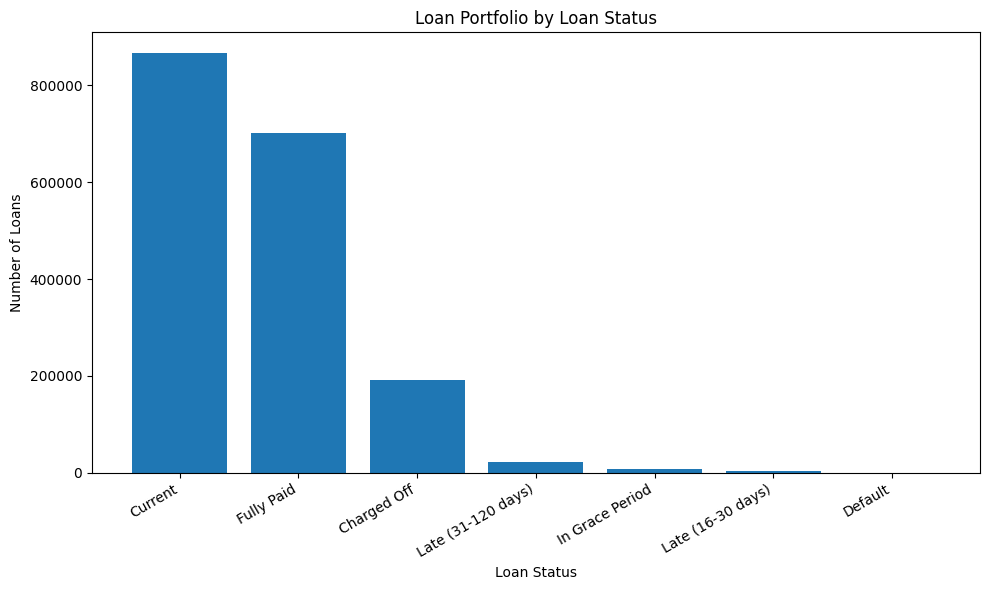

In [ ]:
# ============================================================
# STEP 7.3.1 - LOAN STATUS DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

status_counts = (
    df["loan_status"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Loan Portfolio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

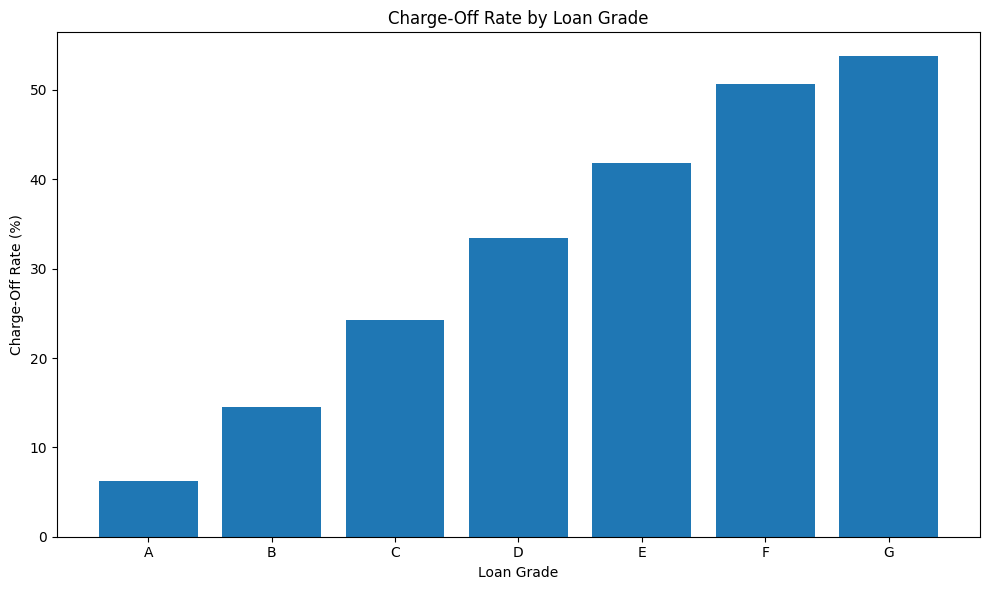

In [ ]:
# ============================================================
# STEP 7.3.2 - GRADE VS CHARGE-OFF RATE
# ============================================================

grade_risk = (
    completed_loans.groupby("grade")
    .agg(
        Loans=("id", "count"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

grade_risk["Charge_Off_Rate_%"] = (
    grade_risk["Charged_Off_Loans"]
    / grade_risk["Loans"]
    * 100
)

# Keep grades in logical order
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_risk["grade"] = pd.Categorical(
    grade_risk["grade"],
    categories=grade_order,
    ordered=True
)

grade_risk = grade_risk.sort_values("grade")

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    grade_risk["grade"],
    grade_risk["Charge_Off_Rate_%"]
)

plt.title("Charge-Off Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Charge-Off Rate (%)")

plt.tight_layout()
plt.show()

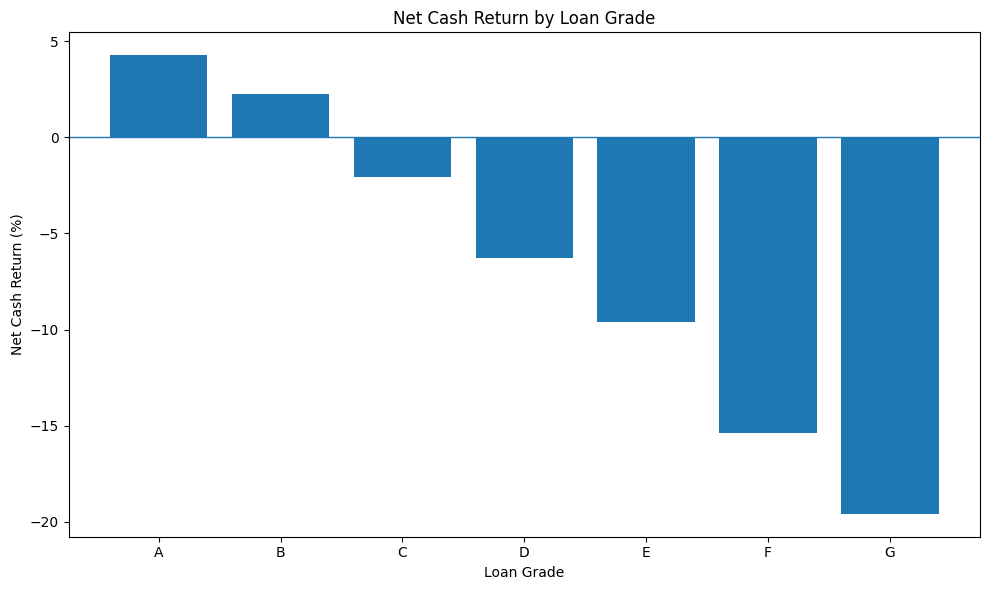

In [ ]:
# ============================================================
# STEP 7.3.3 - GRADE VS NET CASH RETURN
# ============================================================

grade_return = (
    completed_loans.groupby("grade")
    .agg(
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

grade_return["Net_Cash_Return_%"] = (
    grade_return["Net_Cash_Outcome"]
    / grade_return["Funded_Amount"]
    * 100
)

# Keep grades in logical order
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_return["grade"] = pd.Categorical(
    grade_return["grade"],
    categories=grade_order,
    ordered=True
)

grade_return = grade_return.sort_values("grade")

# Plot
plt.figure(figsize=(10, 6))

plt.bar(
    grade_return["grade"],
    grade_return["Net_Cash_Return_%"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Net Cash Return by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Net Cash Return (%)")

plt.tight_layout()
plt.show()

===== VERIFIED HEATMAP DATA =====
grade      term  Net_Cash_Return_%
    A 36 months           4.401375
    A 60 months           1.195056
    B 36 months           3.061451
    B 60 months          -0.821539
    C 36 months           0.102882
    C 60 months          -5.604175
    D 36 months          -3.565666
    D 60 months          -9.422057
    E 36 months          -6.670712
    E 60 months         -10.824505
    F 36 months         -11.351407
    F 60 months         -16.061909
    G 36 months         -19.029570
    G 60 months         -19.677598

===== HEATMAP MATRIX =====
   36 months  60 months
A       4.40       1.20
B       3.06      -0.82
C       0.10      -5.60
D      -3.57      -9.42
E      -6.67     -10.82
F     -11.35     -16.06
G     -19.03     -19.68


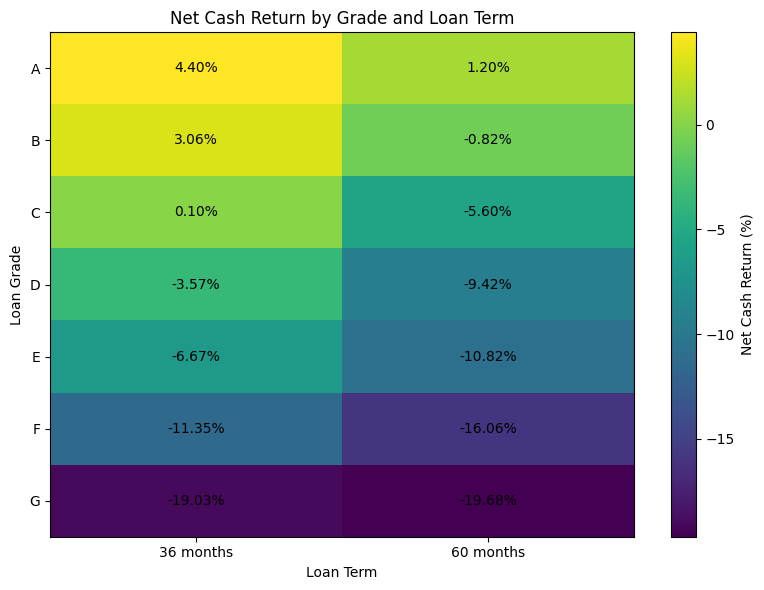

In [ ]:
# ============================================================
# STEP 7.3.4 - GRADE × TERM NET CASH RETURN HEATMAP
# FINAL WORKING VERSION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Copy the verified segment data
heatmap_source = segment_concentration[
    ["grade", "term", "Net_Cash_Return_%"]
].copy()

# Convert labels to clean strings
heatmap_source["grade"] = heatmap_source["grade"].astype(str).str.strip()
heatmap_source["term"] = heatmap_source["term"].astype(str).str.strip()

# Explicit grade and term order
grades = ["A", "B", "C", "D", "E", "F", "G"]
terms = ["36 months", "60 months"]

# Sort using explicit order
heatmap_source["grade_order"] = heatmap_source["grade"].map(
    {grade: i for i, grade in enumerate(grades)}
)

heatmap_source["term_order"] = heatmap_source["term"].map(
    {term: i for i, term in enumerate(terms)}
)

heatmap_source = heatmap_source.sort_values(
    ["grade_order", "term_order"]
)

# Verify the 14 rows
print("===== VERIFIED HEATMAP DATA =====")
print(
    heatmap_source[
        ["grade", "term", "Net_Cash_Return_%"]
    ].to_string(index=False)
)

# Extract values directly in sorted order
heatmap_matrix = (
    heatmap_source["Net_Cash_Return_%"]
    .astype(float)
    .to_numpy()
    .reshape(7, 2)
)

# Display matrix
print("\n===== HEATMAP MATRIX =====")
print(
    pd.DataFrame(
        heatmap_matrix,
        index=grades,
        columns=terms
    ).round(2)
)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    heatmap_matrix,
    aspect="auto"
)

# Axis labels
ax.set_xticks(range(2))
ax.set_xticklabels(terms)

ax.set_yticks(range(7))
ax.set_yticklabels(grades)

ax.set_xlabel("Loan Term")
ax.set_ylabel("Loan Grade")
ax.set_title("Net Cash Return by Grade and Loan Term")

# Add percentage values
for i in range(7):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{heatmap_matrix[i, j]:.2f}%",
            ha="center",
            va="center"
        )

plt.colorbar(
    im,
    ax=ax,
    label="Net Cash Return (%)"
)

plt.tight_layout()
plt.show()

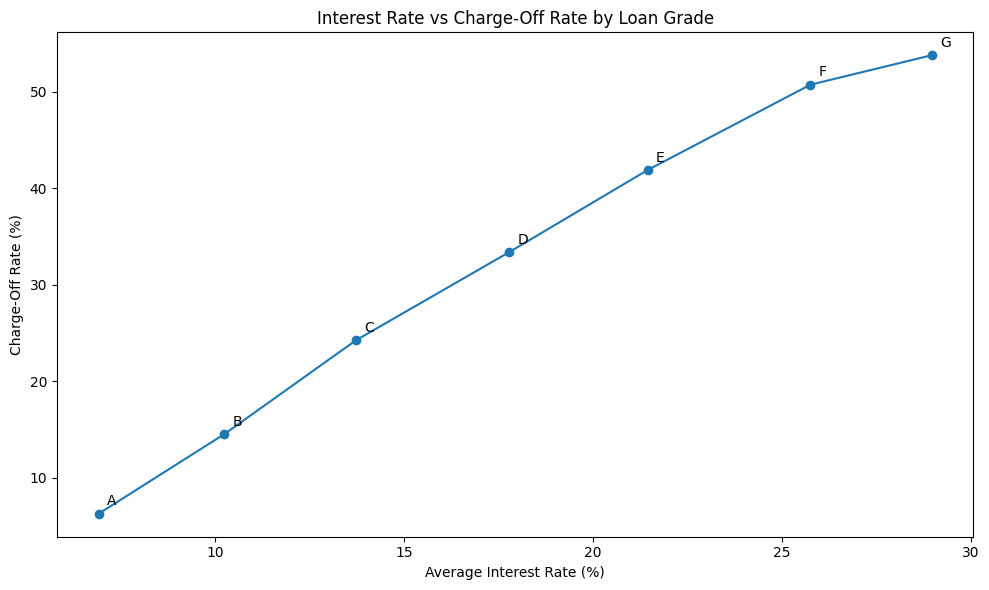

In [ ]:
# ============================================================
# STEP 7.3.5 - INTEREST RATE VS CHARGE-OFF RATE
# ============================================================

# Calculate grade-level pricing and risk
interest_risk = (
    completed_loans.groupby("grade")
    .agg(
        Avg_Interest_Rate=("int_rate", "mean"),
        Loans=("id", "count"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

interest_risk["Charge_Off_Rate_%"] = (
    interest_risk["Charged_Off_Loans"]
    / interest_risk["Loans"]
    * 100
)

# Grade order
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

interest_risk["grade"] = pd.Categorical(
    interest_risk["grade"],
    categories=grade_order,
    ordered=True
)

interest_risk = interest_risk.sort_values("grade")

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    interest_risk["Avg_Interest_Rate"],
    interest_risk["Charge_Off_Rate_%"],
    marker="o"
)

# Add grade labels
for _, row in interest_risk.iterrows():
    plt.annotate(
        row["grade"],
        (
            row["Avg_Interest_Rate"],
            row["Charge_Off_Rate_%"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.title("Interest Rate vs Charge-Off Rate by Loan Grade")
plt.xlabel("Average Interest Rate (%)")
plt.ylabel("Charge-Off Rate (%)")

plt.tight_layout()
plt.show()

===== GRADE EXPOSURE ANALYSIS =====
grade  Loans  Funded_Amount  Exposure_Share_%  Charge_Off_Rate_%  Net_Cash_Return_%
    A 160555   2267785225.0             17.45               6.25               4.27
    B 258153   3446004200.0             26.51              14.50               2.28
    C 261076   3721495675.0             28.63              24.22              -2.04
    D 128444   1990853900.0             15.32              33.38              -6.28
    E  60321   1066159275.0              8.20              41.86              -9.61
    F  19578    381228150.0              2.93              50.70             -15.40
    G   6163    125015725.0              0.96              53.76             -19.59


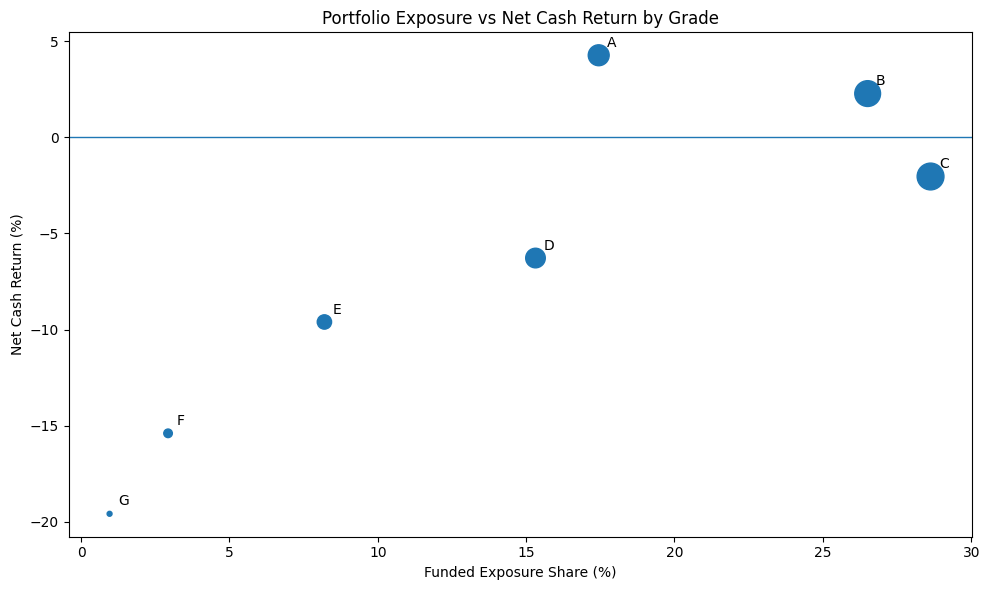

In [ ]:
# ============================================================
# STEP 7.3.6 - EXPOSURE VS NET CASH RETURN
# ============================================================

# Recreate grade-level exposure analysis
grade_exposure = (
    completed_loans.groupby("grade")
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

# Calculate exposure share
grade_exposure["Exposure_Share_%"] = (
    grade_exposure["Funded_Amount"]
    / grade_exposure["Funded_Amount"].sum()
    * 100
)

# Calculate charge-off rate
grade_exposure["Charge_Off_Rate_%"] = (
    grade_exposure["Charged_Off_Loans"]
    / grade_exposure["Loans"]
    * 100
)

# Calculate net cash return
grade_exposure["Net_Cash_Return_%"] = (
    grade_exposure["Net_Cash_Outcome"]
    / grade_exposure["Funded_Amount"]
    * 100
)

# Order grades
grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_exposure["grade"] = pd.Categorical(
    grade_exposure["grade"],
    categories=grade_order,
    ordered=True
)

grade_exposure = grade_exposure.sort_values("grade")

# Display verification
print("===== GRADE EXPOSURE ANALYSIS =====")

print(
    grade_exposure[
        [
            "grade",
            "Loans",
            "Funded_Amount",
            "Exposure_Share_%",
            "Charge_Off_Rate_%",
            "Net_Cash_Return_%"
        ]
    ].round(2).to_string(index=False)
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    grade_exposure["Exposure_Share_%"],
    grade_exposure["Net_Cash_Return_%"],
    s=grade_exposure["Funded_Amount"] / 10_000_000
)

# Grade labels
for _, row in grade_exposure.iterrows():
    plt.annotate(
        row["grade"],
        (
            row["Exposure_Share_%"],
            row["Net_Cash_Return_%"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Zero-return reference
plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Portfolio Exposure vs Net Cash Return by Grade")
plt.xlabel("Funded Exposure Share (%)")
plt.ylabel("Net Cash Return (%)")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 7.4 - EXECUTIVE DASHBOARD SUMMARY
# ============================================================

# Portfolio KPIs
total_loans = len(df)

total_funded = df["funded_amnt"].sum()

overall_charge_off_rate = (
    (df["loan_status"] == "Charged Off").sum()
    / len(df)
    * 100
)

average_interest_rate = df["int_rate"].mean()

# Current exposure
current_exposure = df.loc[
    df["loan_status"] == "Current",
    "funded_amnt"
].sum()

current_exposure_share = (
    current_exposure / total_funded * 100
)

# Completed loans
completed_count = len(completed_loans)

completed_funded = completed_loans["funded_amnt"].sum()

completed_net_cash = completed_loans["net_cash_outcome"].sum()

completed_net_return = (
    completed_net_cash / completed_funded * 100
)

# Grade performance
best_grade = grade_exposure.loc[
    grade_exposure["Net_Cash_Return_%"].idxmax(),
    "grade"
]

worst_grade = grade_exposure.loc[
    grade_exposure["Net_Cash_Return_%"].idxmin(),
    "grade"
]

# Best grade-term segment
best_segment = segment_concentration.loc[
    segment_concentration["Net_Cash_Return_%"].idxmax()
]

# Largest negative exposure segment
largest_negative = grade_exposure[
    grade_exposure["Net_Cash_Return_%"] < 0
].sort_values(
    "Funded_Amount",
    ascending=False
).iloc[0]


# ============================================================
# CREATE SUMMARY TABLE
# ============================================================

dashboard_summary = pd.DataFrame({
    "KPI": [
        "Total Loans",
        "Total Funded Amount",
        "Overall Charge-Off Rate",
        "Average Interest Rate",
        "Current Exposure",
        "Current Exposure Share",
        "Completed Loans",
        "Completed Funded Amount",
        "Completed Net Cash Outcome",
        "Completed Net Cash Return",
        "Best Performing Grade",
        "Worst Performing Grade",
        "Best Grade-Term Segment",
        "Largest Negative Exposure Grade"
    ],

    "Value": [
        f"{total_loans:,}",
        f"${total_funded:,.2f}",
        f"{overall_charge_off_rate:.2f}%",
        f"{average_interest_rate:.2f}%",
        f"${current_exposure:,.2f}",
        f"{current_exposure_share:.2f}%",
        f"{completed_count:,}",
        f"${completed_funded:,.2f}",
        f"${completed_net_cash:,.2f}",
        f"{completed_net_return:.2f}%",
        str(best_grade),
        str(worst_grade),
        f"{best_segment['grade']} - {best_segment['term']}",
        str(largest_negative["grade"])
    ]
})

print("===== EXECUTIVE DASHBOARD SUMMARY =====")
display(dashboard_summary)

===== EXECUTIVE DASHBOARD SUMMARY =====


,KPI,Value
0,Total Loans,"1,794,323"
1,Total Funded Amount,"$27,339,370,100.00"
2,Overall Charge-Off Rate,10.70%
3,Average Interest Rate,12.90%
4,Current Exposure,"$13,764,322,725.00"
5,Current Exposure Share,50.35%
6,Completed Loans,"894,290"
7,Completed Funded Amount,"$12,998,542,150.00"
8,Completed Net Cash Outcome,"$-211,138,952.80"
9,Completed Net Cash Return,-1.62%


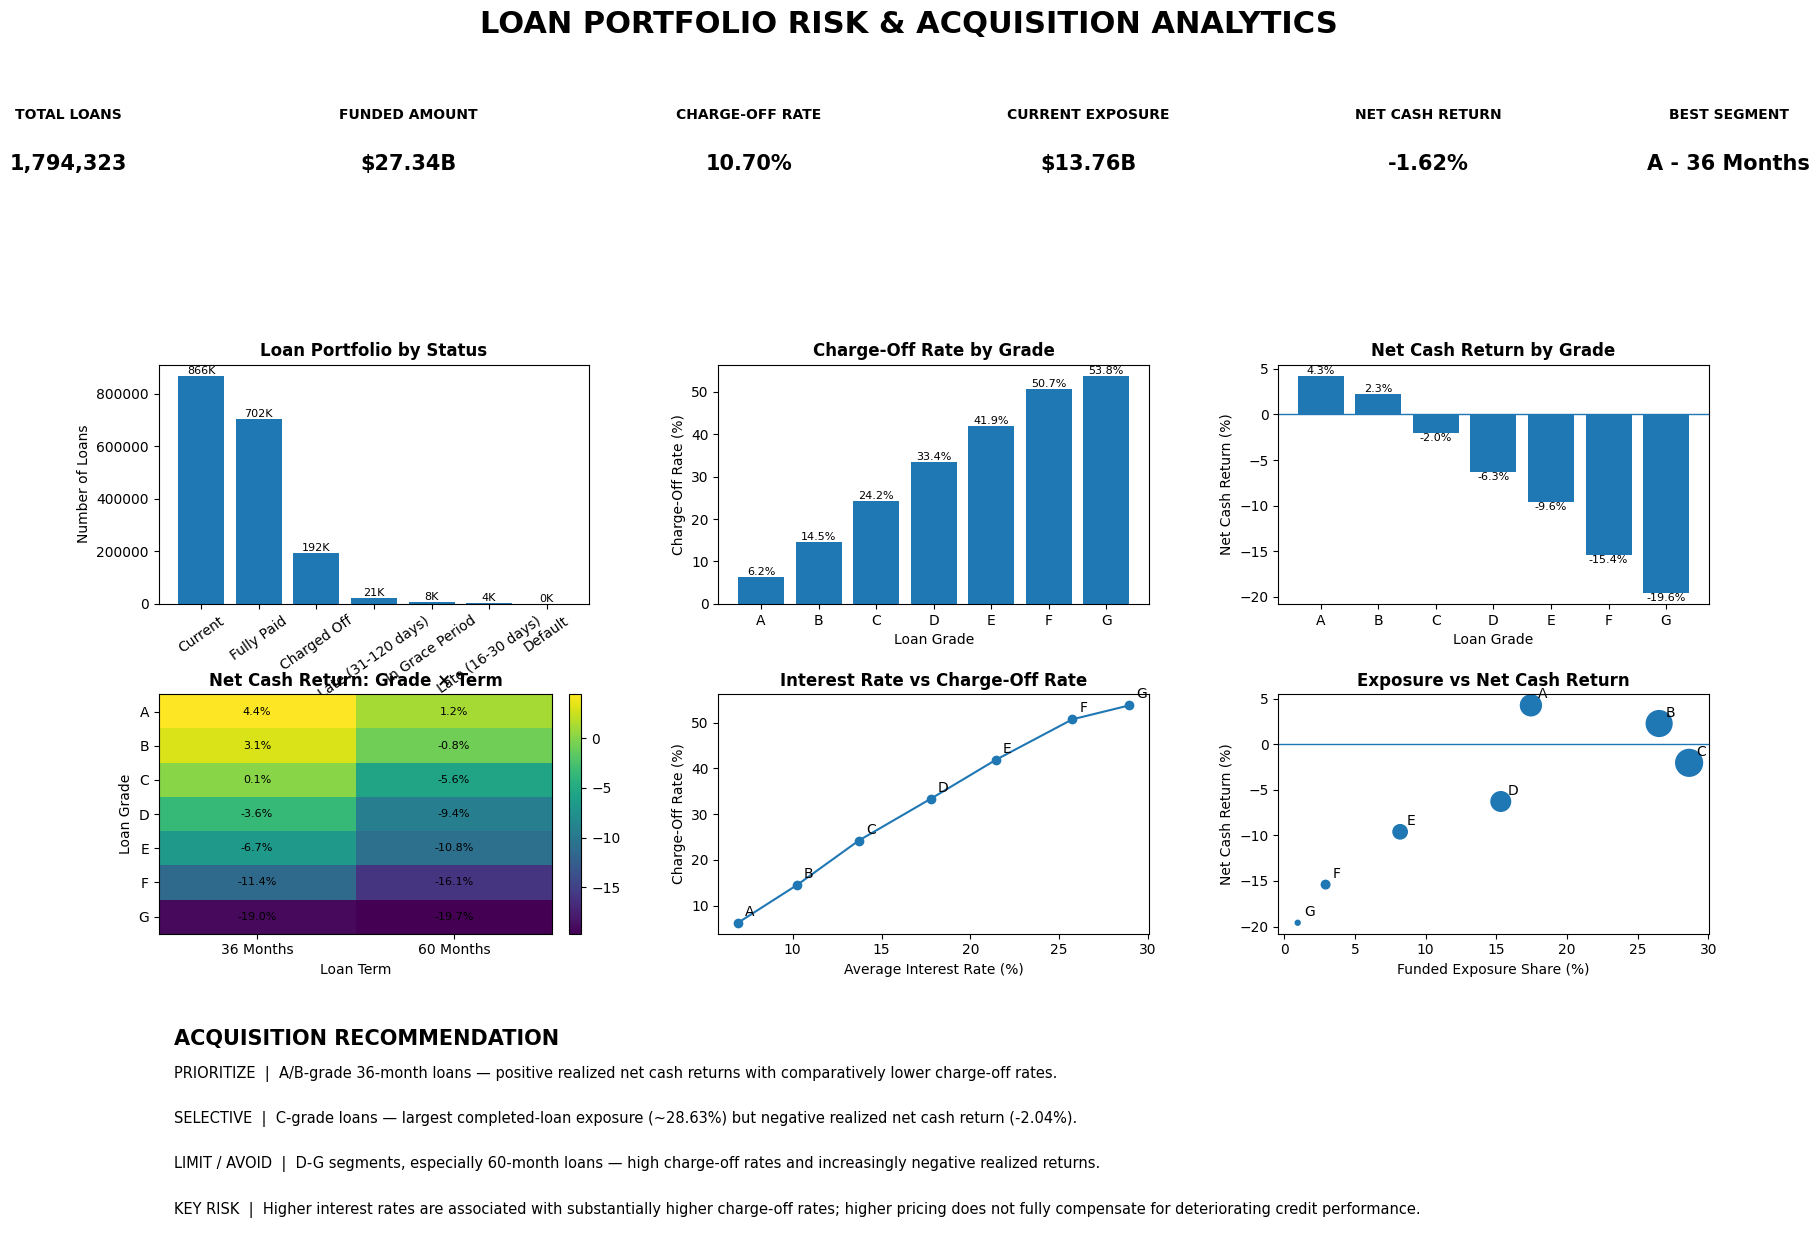

In [ ]:
# ============================================================
# STEP 7.5.1 - FINAL EXECUTIVE DASHBOARD
# CORRECTED PRESENTATION VERSION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. BASIC KPI CALCULATIONS
# ------------------------------------------------------------

total_loans = len(df)

total_funded = df["funded_amnt"].sum()

charge_off_rate = (
    (df["loan_status"] == "Charged Off").sum()
    / len(df)
    * 100
)

avg_interest_rate = df["int_rate"].mean()

current_exposure = df.loc[
    df["loan_status"] == "Current",
    "funded_amnt"
].sum()

current_exposure_share = (
    current_exposure / total_funded * 100
)

completed_funded = completed_loans["funded_amnt"].sum()

completed_net_cash = completed_loans["net_cash_outcome"].sum()

completed_net_return = (
    completed_net_cash / completed_funded * 100
)


# ------------------------------------------------------------
# 2. LOAN STATUS DATA
# ------------------------------------------------------------

status_counts = (
    df["loan_status"]
    .value_counts()
)


# ------------------------------------------------------------
# 3. GRADE RISK DATA
# ------------------------------------------------------------

grade_risk = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Loans=("id", "count"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

grade_risk["Charge_Off_Rate_%"] = (
    grade_risk["Charged_Off_Loans"]
    / grade_risk["Loans"]
    * 100
)

grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_risk["grade"] = pd.Categorical(
    grade_risk["grade"],
    categories=grade_order,
    ordered=True
)

grade_risk = grade_risk.sort_values("grade")


# ------------------------------------------------------------
# 4. GRADE RETURN DATA
# ------------------------------------------------------------

grade_return = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

grade_return["Net_Cash_Return_%"] = (
    grade_return["Net_Cash_Outcome"]
    / grade_return["Funded_Amount"]
    * 100
)

grade_return["grade"] = pd.Categorical(
    grade_return["grade"],
    categories=grade_order,
    ordered=True
)

grade_return = grade_return.sort_values("grade")


# ------------------------------------------------------------
# 5. GRADE EXPOSURE DATA
# ------------------------------------------------------------

grade_exposure = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

grade_exposure["Exposure_Share_%"] = (
    grade_exposure["Funded_Amount"]
    / grade_exposure["Funded_Amount"].sum()
    * 100
)

grade_exposure["Net_Cash_Return_%"] = (
    grade_exposure["Net_Cash_Outcome"]
    / grade_exposure["Funded_Amount"]
    * 100
)

grade_exposure["grade"] = pd.Categorical(
    grade_exposure["grade"],
    categories=grade_order,
    ordered=True
)

grade_exposure = grade_exposure.sort_values("grade")


# ------------------------------------------------------------
# 6. INTEREST RATE VS RISK
# ------------------------------------------------------------

interest_risk = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Avg_Interest_Rate=("int_rate", "mean"),
        Loans=("id", "count"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

interest_risk["Charge_Off_Rate_%"] = (
    interest_risk["Charged_Off_Loans"]
    / interest_risk["Loans"]
    * 100
)

interest_risk["grade"] = pd.Categorical(
    interest_risk["grade"],
    categories=grade_order,
    ordered=True
)

interest_risk = interest_risk.sort_values("grade")


# ------------------------------------------------------------
# 7. GRADE × TERM DATA
# ------------------------------------------------------------

segment_concentration = (
    completed_loans
    .groupby(
        ["grade", "term"],
        observed=True
    )
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

segment_concentration["Net_Cash_Return_%"] = (
    segment_concentration["Net_Cash_Outcome"]
    / segment_concentration["Funded_Amount"]
    * 100
)

# Sort explicitly
segment_concentration["grade_order"] = (
    segment_concentration["grade"]
    .astype(str)
    .map({g: i for i, g in enumerate(grade_order)})
)

segment_concentration["term_order"] = (
    segment_concentration["term"]
    .astype(str)
    .map({
        "36 months": 0,
        "60 months": 1
    })
)

segment_concentration = (
    segment_concentration
    .sort_values(["grade_order", "term_order"])
    .reset_index(drop=True)
)

# Extract directly from verified sorted 14 rows
heatmap_matrix = (
    segment_concentration["Net_Cash_Return_%"]
    .astype(float)
    .to_numpy()
    .reshape(7, 2)
)


# ------------------------------------------------------------
# 8. CREATE DASHBOARD
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(20, 14)
)

gs = fig.add_gridspec(
    4,
    3,
    height_ratios=[0.70, 1.35, 1.35, 1.15],
    hspace=0.45,
    wspace=0.30
)

fig.suptitle(
    "LOAN PORTFOLIO RISK & ACQUISITION ANALYTICS",
    fontsize=22,
    fontweight="bold",
    y=0.98
)


# ============================================================
# KPI SECTION
# ============================================================

kpis = [
    ("TOTAL LOANS", f"{total_loans:,}"),
    ("FUNDED AMOUNT", f"${total_funded/1e9:.2f}B"),
    ("CHARGE-OFF RATE", f"{charge_off_rate:.2f}%"),
    ("CURRENT EXPOSURE", f"${current_exposure/1e9:.2f}B"),
    ("NET CASH RETURN", f"{completed_net_return:.2f}%"),
    ("BEST SEGMENT", "A - 36 Months")
]

positions = [
    (0.08, 0.905),
    (0.25, 0.905),
    (0.42, 0.905),
    (0.59, 0.905),
    (0.76, 0.905),
    (0.91, 0.905)
]

for (label, value), (x, y) in zip(kpis, positions):

    fig.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    fig.text(
        x,
        y - 0.035,
        value,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold"
    )


# ============================================================
# CHART 1 - LOAN STATUS
# ============================================================

ax1 = fig.add_subplot(gs[1, 0])

ax1.bar(
    status_counts.index,
    status_counts.values
)

ax1.set_title(
    "Loan Portfolio by Status",
    fontweight="bold"
)

ax1.set_ylabel("Number of Loans")

ax1.tick_params(
    axis="x",
    rotation=35
)

for i, value in enumerate(status_counts.values):

    ax1.text(
        i,
        value,
        f"{value/1000:.0f}K",
        ha="center",
        va="bottom",
        fontsize=8
    )


# ============================================================
# CHART 2 - CHARGE-OFF RATE
# ============================================================

ax2 = fig.add_subplot(gs[1, 1])

values = grade_risk["Charge_Off_Rate_%"].to_numpy()

ax2.bar(
    grade_order,
    values
)

ax2.set_title(
    "Charge-Off Rate by Grade",
    fontweight="bold"
)

ax2.set_xlabel("Loan Grade")
ax2.set_ylabel("Charge-Off Rate (%)")

for i, value in enumerate(values):

    ax2.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )


# ============================================================
# CHART 3 - NET CASH RETURN
# ============================================================

ax3 = fig.add_subplot(gs[1, 2])

values = grade_return["Net_Cash_Return_%"].to_numpy()

ax3.bar(
    grade_order,
    values
)

ax3.axhline(
    y=0,
    linewidth=1
)

ax3.set_title(
    "Net Cash Return by Grade",
    fontweight="bold"
)

ax3.set_xlabel("Loan Grade")
ax3.set_ylabel("Net Cash Return (%)")

for i, value in enumerate(values):

    ax3.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=8
    )


# ============================================================
# CHART 4 - GRADE × TERM HEATMAP
# ============================================================

ax4 = fig.add_subplot(gs[2, 0])

im = ax4.imshow(
    heatmap_matrix,
    aspect="auto"
)

ax4.set_title(
    "Net Cash Return: Grade × Term",
    fontweight="bold"
)

ax4.set_xticks([0, 1])
ax4.set_xticklabels(
    ["36 Months", "60 Months"]
)

ax4.set_yticks(range(7))
ax4.set_yticklabels(grade_order)

ax4.set_xlabel("Loan Term")
ax4.set_ylabel("Loan Grade")

for i in range(7):

    for j in range(2):

        ax4.text(
            j,
            i,
            f"{heatmap_matrix[i, j]:.1f}%",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(
    im,
    ax=ax4,
    fraction=0.046,
    pad=0.04
)


# ============================================================
# CHART 5 - INTEREST RATE VS CHARGE-OFF
# ============================================================

ax5 = fig.add_subplot(gs[2, 1])

ax5.plot(
    interest_risk["Avg_Interest_Rate"].to_numpy(),
    interest_risk["Charge_Off_Rate_%"].to_numpy(),
    marker="o"
)

for _, row in interest_risk.iterrows():

    ax5.annotate(
        str(row["grade"]),
        (
            row["Avg_Interest_Rate"],
            row["Charge_Off_Rate_%"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax5.set_title(
    "Interest Rate vs Charge-Off Rate",
    fontweight="bold"
)

ax5.set_xlabel("Average Interest Rate (%)")
ax5.set_ylabel("Charge-Off Rate (%)")


# ============================================================
# CHART 6 - EXPOSURE VS NET CASH RETURN
# ============================================================

ax6 = fig.add_subplot(gs[2, 2])

ax6.scatter(
    grade_exposure["Exposure_Share_%"].to_numpy(),
    grade_exposure["Net_Cash_Return_%"].to_numpy(),
    s=grade_exposure["Funded_Amount"].to_numpy() / 10_000_000
)

for _, row in grade_exposure.iterrows():

    ax6.annotate(
        str(row["grade"]),
        (
            row["Exposure_Share_%"],
            row["Net_Cash_Return_%"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax6.axhline(
    y=0,
    linewidth=1
)

ax6.set_title(
    "Exposure vs Net Cash Return",
    fontweight="bold"
)

ax6.set_xlabel("Funded Exposure Share (%)")
ax6.set_ylabel("Net Cash Return (%)")


# ============================================================
# RECOMMENDATION PANEL
# ============================================================

ax7 = fig.add_subplot(gs[3, :])

ax7.axis("off")

ax7.text(
    0.01,
    0.90,
    "ACQUISITION RECOMMENDATION",
    fontsize=15,
    fontweight="bold"
)

recommendation = (
    "PRIORITIZE  |  A/B-grade 36-month loans — positive realized "
    "net cash returns with comparatively lower charge-off rates.\n\n"

    "SELECTIVE  |  C-grade loans — largest completed-loan exposure "
    "(~28.63%) but negative realized net cash return (-2.04%).\n\n"

    "LIMIT / AVOID  |  D-G segments, especially 60-month loans — "
    "high charge-off rates and increasingly negative realized returns.\n\n"

    "KEY RISK  |  Higher interest rates are associated with substantially "
    "higher charge-off rates; higher pricing does not fully compensate "
    "for deteriorating credit performance."
)

ax7.text(
    0.01,
    0.05,
    recommendation,
    fontsize=10.5,
    verticalalignment="bottom",
    linespacing=1.6
)

plt.show()

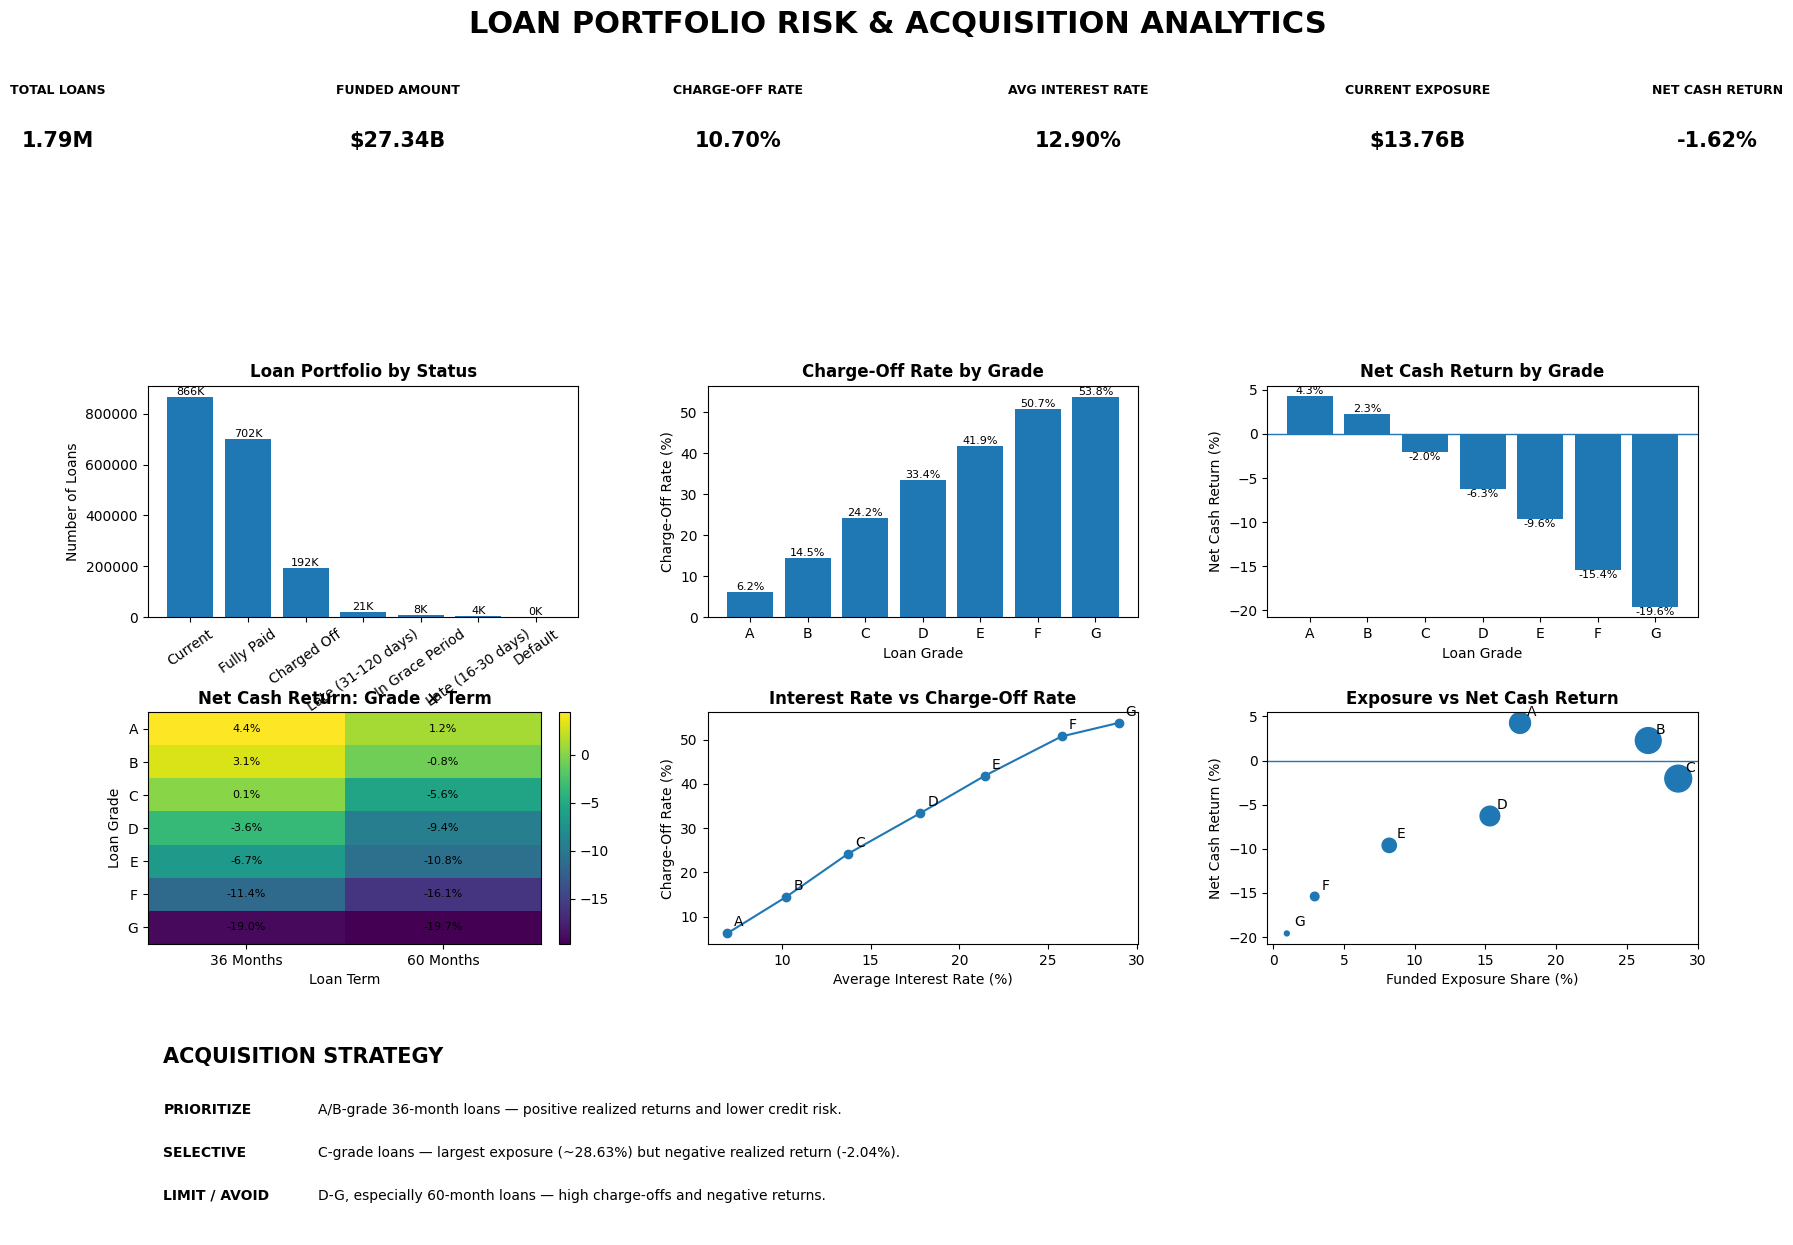

In [ ]:
# ============================================================
# STEP 7.5.2 - FINAL PRESENTATION-READY DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# KPI VALUES
# ------------------------------------------------------------

total_loans = len(df)

total_funded = df["funded_amnt"].sum()

charge_off_rate = (
    (df["loan_status"] == "Charged Off").mean() * 100
)

avg_interest_rate = df["int_rate"].mean()

current_exposure = df.loc[
    df["loan_status"] == "Current",
    "funded_amnt"
].sum()

current_exposure_share = (
    current_exposure / total_funded * 100
)

completed_funded = completed_loans["funded_amnt"].sum()

completed_net_cash = completed_loans["net_cash_outcome"].sum()

completed_net_return = (
    completed_net_cash / completed_funded * 100
)


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

status_counts = df["loan_status"].value_counts()

grade_order = ["A", "B", "C", "D", "E", "F", "G"]

grade_risk = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Loans=("id", "count"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

grade_risk["Charge_Off_Rate_%"] = (
    grade_risk["Charged_Off_Loans"]
    / grade_risk["Loans"] * 100
)

grade_risk["grade"] = pd.Categorical(
    grade_risk["grade"],
    categories=grade_order,
    ordered=True
)

grade_risk = grade_risk.sort_values("grade")


grade_return = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

grade_return["Net_Cash_Return_%"] = (
    grade_return["Net_Cash_Outcome"]
    / grade_return["Funded_Amount"] * 100
)

grade_return["grade"] = pd.Categorical(
    grade_return["grade"],
    categories=grade_order,
    ordered=True
)

grade_return = grade_return.sort_values("grade")


grade_exposure = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

grade_exposure["Exposure_Share_%"] = (
    grade_exposure["Funded_Amount"]
    / grade_exposure["Funded_Amount"].sum() * 100
)

grade_exposure["Net_Cash_Return_%"] = (
    grade_exposure["Net_Cash_Outcome"]
    / grade_exposure["Funded_Amount"] * 100
)

grade_exposure["grade"] = pd.Categorical(
    grade_exposure["grade"],
    categories=grade_order,
    ordered=True
)

grade_exposure = grade_exposure.sort_values("grade")


interest_risk = (
    completed_loans
    .groupby("grade", observed=True)
    .agg(
        Avg_Interest_Rate=("int_rate", "mean"),
        Loans=("id", "count"),
        Charged_Off_Loans=(
            "loan_status",
            lambda x: (x == "Charged Off").sum()
        )
    )
    .reset_index()
)

interest_risk["Charge_Off_Rate_%"] = (
    interest_risk["Charged_Off_Loans"]
    / interest_risk["Loans"] * 100
)

interest_risk["grade"] = pd.Categorical(
    interest_risk["grade"],
    categories=grade_order,
    ordered=True
)

interest_risk = interest_risk.sort_values("grade")


segment_concentration = (
    completed_loans
    .groupby(["grade", "term"], observed=True)
    .agg(
        Loans=("id", "count"),
        Funded_Amount=("funded_amnt", "sum"),
        Net_Cash_Outcome=("net_cash_outcome", "sum")
    )
    .reset_index()
)

segment_concentration["Net_Cash_Return_%"] = (
    segment_concentration["Net_Cash_Outcome"]
    / segment_concentration["Funded_Amount"] * 100
)

segment_concentration["grade_order"] = (
    segment_concentration["grade"]
    .astype(str)
    .map({g: i for i, g in enumerate(grade_order)})
)

segment_concentration["term_order"] = (
    segment_concentration["term"]
    .astype(str)
    .map({
        "36 months": 0,
        "60 months": 1
    })
)

segment_concentration = (
    segment_concentration
    .sort_values(["grade_order", "term_order"])
    .reset_index(drop=True)
)

heatmap_matrix = (
    segment_concentration["Net_Cash_Return_%"]
    .to_numpy()
    .reshape(7, 2)
)


# ------------------------------------------------------------
# DASHBOARD CANVAS
# ------------------------------------------------------------

fig = plt.figure(figsize=(20, 14))

gs = fig.add_gridspec(
    4,
    3,
    height_ratios=[0.75, 1.30, 1.30, 1.10],
    hspace=0.48,
    wspace=0.30
)

fig.suptitle(
    "LOAN PORTFOLIO RISK & ACQUISITION ANALYTICS",
    fontsize=22,
    fontweight="bold",
    y=0.985
)


# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

kpis = [
    ("TOTAL LOANS", f"{total_loans/1e6:.2f}M"),
    ("FUNDED AMOUNT", f"${total_funded/1e9:.2f}B"),
    ("CHARGE-OFF RATE", f"{charge_off_rate:.2f}%"),
    ("AVG INTEREST RATE", f"{avg_interest_rate:.2f}%"),
    ("CURRENT EXPOSURE", f"${current_exposure/1e9:.2f}B"),
    ("NET CASH RETURN", f"{completed_net_return:.2f}%")
]

positions = [
    0.08, 0.25, 0.42, 0.59, 0.76, 0.91
]

for (label, value), x in zip(kpis, positions):

    fig.text(
        x,
        0.925,
        label,
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    fig.text(
        x,
        0.887,
        value,
        ha="center",
        fontsize=15,
        fontweight="bold"
    )


# ------------------------------------------------------------
# CHART 1
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[1, 0])

ax1.bar(
    status_counts.index,
    status_counts.values
)

ax1.set_title(
    "Loan Portfolio by Status",
    fontweight="bold"
)

ax1.set_ylabel("Number of Loans")

ax1.tick_params(
    axis="x",
    rotation=35
)

for i, value in enumerate(status_counts.values):

    ax1.text(
        i,
        value,
        f"{value/1000:.0f}K",
        ha="center",
        va="bottom",
        fontsize=8
    )


# ------------------------------------------------------------
# CHART 2
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[1, 1])

values = grade_risk["Charge_Off_Rate_%"].to_numpy()

ax2.bar(
    grade_order,
    values
)

ax2.set_title(
    "Charge-Off Rate by Grade",
    fontweight="bold"
)

ax2.set_xlabel("Loan Grade")
ax2.set_ylabel("Charge-Off Rate (%)")

for i, value in enumerate(values):

    ax2.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )


# ------------------------------------------------------------
# CHART 3
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[1, 2])

values = grade_return["Net_Cash_Return_%"].to_numpy()

ax3.bar(
    grade_order,
    values
)

ax3.axhline(
    y=0,
    linewidth=1
)

ax3.set_title(
    "Net Cash Return by Grade",
    fontweight="bold"
)

ax3.set_xlabel("Loan Grade")
ax3.set_ylabel("Net Cash Return (%)")

for i, value in enumerate(values):

    ax3.text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=8
    )


# ------------------------------------------------------------
# CHART 4 - HEATMAP
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[2, 0])

im = ax4.imshow(
    heatmap_matrix,
    aspect="auto"
)

ax4.set_title(
    "Net Cash Return: Grade × Term",
    fontweight="bold"
)

ax4.set_xticks([0, 1])
ax4.set_xticklabels(
    ["36 Months", "60 Months"]
)

ax4.set_yticks(range(7))
ax4.set_yticklabels(grade_order)

ax4.set_xlabel("Loan Term")
ax4.set_ylabel("Loan Grade")

for i in range(7):

    for j in range(2):

        ax4.text(
            j,
            i,
            f"{heatmap_matrix[i,j]:.1f}%",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(
    im,
    ax=ax4,
    fraction=0.046,
    pad=0.04
)


# ------------------------------------------------------------
# CHART 5
# ------------------------------------------------------------

ax5 = fig.add_subplot(gs[2, 1])

ax5.plot(
    interest_risk["Avg_Interest_Rate"],
    interest_risk["Charge_Off_Rate_%"],
    marker="o"
)

for _, row in interest_risk.iterrows():

    ax5.annotate(
        str(row["grade"]),
        (
            row["Avg_Interest_Rate"],
            row["Charge_Off_Rate_%"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax5.set_title(
    "Interest Rate vs Charge-Off Rate",
    fontweight="bold"
)

ax5.set_xlabel("Average Interest Rate (%)")
ax5.set_ylabel("Charge-Off Rate (%)")


# ------------------------------------------------------------
# CHART 6
# ------------------------------------------------------------

ax6 = fig.add_subplot(gs[2, 2])

ax6.scatter(
    grade_exposure["Exposure_Share_%"],
    grade_exposure["Net_Cash_Return_%"],
    s=grade_exposure["Funded_Amount"] / 10_000_000
)

for _, row in grade_exposure.iterrows():

    ax6.annotate(
        str(row["grade"]),
        (
            row["Exposure_Share_%"],
            row["Net_Cash_Return_%"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax6.axhline(
    y=0,
    linewidth=1
)

ax6.set_title(
    "Exposure vs Net Cash Return",
    fontweight="bold"
)

ax6.set_xlabel("Funded Exposure Share (%)")
ax6.set_ylabel("Net Cash Return (%)")


# ------------------------------------------------------------
# RECOMMENDATION PANEL
# ------------------------------------------------------------

ax7 = fig.add_subplot(gs[3, :])

ax7.axis("off")

ax7.text(
    0.01,
    0.88,
    "ACQUISITION STRATEGY",
    fontsize=15,
    fontweight="bold"
)

ax7.text(
    0.01,
    0.62,
    "PRIORITIZE",
    fontsize=10,
    fontweight="bold"
)

ax7.text(
    0.11,
    0.62,
    "A/B-grade 36-month loans — positive realized returns and lower credit risk.",
    fontsize=10
)

ax7.text(
    0.01,
    0.40,
    "SELECTIVE",
    fontsize=10,
    fontweight="bold"
)

ax7.text(
    0.11,
    0.40,
    "C-grade loans — largest exposure (~28.63%) but negative realized return (-2.04%).",
    fontsize=10
)

ax7.text(
    0.01,
    0.18,
    "LIMIT / AVOID",
    fontsize=10,
    fontweight="bold"
)

ax7.text(
    0.11,
    0.18,
    "D-G, especially 60-month loans — high charge-offs and negative returns.",
    fontsize=10
)

plt.show()

# Part II — SQL Analysis

SQL analysis was performed using **DuckDB within Google Colab**. The prepared pandas dataframe was registered as the `loan_portfolio` SQL table and queried for portfolio overview, loan status, grade and term risk, borrower-risk segmentation, financial/recovery performance, and acquisition analysis.


In [ ]:
# ============================================================
# STEP 8.1 - SQL ENVIRONMENT SETUP
# ============================================================

!pip -q install duckdb

import duckdb
import pandas as pd

# Create SQL connection
con = duckdb.connect()

# Register the existing pandas dataframe as a SQL table
con.register("loan_portfolio", df)

print("===== SQL ENVIRONMENT READY =====")

# Basic verification
result = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT id) AS unique_loans
    FROM loan_portfolio
""").df()

display(result)

===== SQL ENVIRONMENT READY =====


,total_rows,unique_loans
0,1794323,1794323


In [ ]:
# ============================================================
# STEP 8.2 - SQL PORTFOLIO OVERVIEW
# ============================================================

portfolio_sql = con.execute("""
    SELECT
        COUNT(*) AS total_loans,

        SUM(funded_amnt) AS total_funded_amount,

        AVG(loan_amnt) AS average_loan_amount,

        AVG(int_rate) AS average_interest_rate,

        SUM(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN funded_amnt
                ELSE 0
            END
        ) AS charged_off_funded_amount,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio
""").df()

print("===== SQL PORTFOLIO OVERVIEW =====")
display(portfolio_sql)

===== SQL PORTFOLIO OVERVIEW =====


,total_loans,total_funded_amount,average_loan_amount,average_interest_rate,charged_off_funded_amount,charged_off_loans,charge_off_rate
0,1794323,2.733937e+10,15236.609072,12.901638,3.013154e+09,192060,10.7


In [ ]:
# ============================================================
# STEP 8.3 - LOAN STATUS ANALYSIS
# ============================================================

loan_status_sql = con.execute("""
    SELECT
        loan_status,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
            2
        ) AS portfolio_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate

    FROM loan_portfolio

    GROUP BY loan_status

    ORDER BY number_of_loans DESC
""").df()

print("===== SQL LOAN STATUS ANALYSIS =====")

display(loan_status_sql)

===== SQL LOAN STATUS ANALYSIS =====


,loan_status,number_of_loans,funded_amount,portfolio_share_pct,average_interest_rate
0,Current,866392,1.376432e+10,48.29,12.73
1,Fully Paid,702191,9.984827e+09,39.13,12.25
2,Charged Off,192060,3.013154e+09,10.70,15.60
3,Late (31-120 days),21130,3.574886e+08,1.18,15.61
4,In Grace Period,8235,1.449508e+08,0.46,15.41
5,Late (16-30 days),4276,7.406582e+07,0.24,15.37
6,Default,39,5.620250e+05,0.00,16.28


In [ ]:
# ============================================================
# STEP 8.4 - GRADE-WISE CREDIT RISK ANALYSIS
# ============================================================

grade_risk_sql = con.execute("""
    SELECT
        grade,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(loan_amnt),
            2
        ) AS average_loan_amount,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY grade

    ORDER BY grade
""").df()

print("===== SQL GRADE-WISE CREDIT RISK =====")

display(grade_risk_sql)

===== SQL GRADE-WISE CREDIT RISK =====


,grade,number_of_loans,funded_amount,exposure_share_pct,average_loan_amount,average_interest_rate,charged_off_loans,charge_off_rate
0,A,358156,5.320402e+09,19.46,14855.01,6.99,10032,2.80
1,B,526610,7.608077e+09,27.83,14447.29,10.46,37435,7.11
2,C,524739,7.996466e+09,29.25,15238.96,14.03,63228,12.05
3,D,247524,3.939052e+09,14.41,15913.82,18.33,42872,17.32
4,E,99880,1.740302e+09,6.37,17423.93,22.31,25253,25.28
5,F,28568,5.555081e+08,2.03,19445.12,26.34,9927,34.75
6,G,8846,1.795633e+08,0.66,20298.82,29.29,3313,37.45


In [ ]:
# ============================================================
# STEP 8.5 - TERM-WISE PORTFOLIO ANALYSIS
# ============================================================

term_sql = con.execute("""
    SELECT
        term,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(loan_amnt),
            2
        ) AS average_loan_amount,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY term

    ORDER BY term
""").df()

print("===== SQL TERM-WISE PORTFOLIO ANALYSIS =====")

display(term_sql)

===== SQL TERM-WISE PORTFOLIO ANALYSIS =====


,term,number_of_loans,funded_amount,exposure_share_pct,average_loan_amount,average_interest_rate,charged_off_loans,charge_off_rate
0,36 months,1271758,1.639060e+10,59.95,12888.16,11.76,119429,9.39
1,60 months,522565,1.094877e+10,40.05,20952.00,15.67,72631,13.90


In [ ]:
# ============================================================
# STEP 8.6 - FICO RISK SEGMENTATION
# FINAL CORRECTED VERSION
# ============================================================

fico_sql = con.execute("""
    SELECT
        CASE
            WHEN fico_range_low < 660
                THEN '<660'
            WHEN fico_range_low = 660
                THEN '660-679'
            WHEN fico_range_low = 680
                THEN '680-699'
            WHEN fico_range_low = 700
                THEN '700-719'
            WHEN fico_range_low = 720
                THEN '720-739'
            WHEN fico_range_low = 740
                THEN '740-759'
            WHEN fico_range_low >= 760
                THEN '760+'
            ELSE 'Unknown'
        END AS fico_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    WHERE fico_range_low IS NOT NULL

    GROUP BY
        CASE
            WHEN fico_range_low < 660
                THEN '<660'
            WHEN fico_range_low = 660
                THEN '660-679'
            WHEN fico_range_low = 680
                THEN '680-699'
            WHEN fico_range_low = 700
                THEN '700-719'
            WHEN fico_range_low = 720
                THEN '720-739'
            WHEN fico_range_low = 740
                THEN '740-759'
            WHEN fico_range_low >= 760
                THEN '760+'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE fico_band
            WHEN '<660' THEN 1
            WHEN '660-679' THEN 2
            WHEN '680-699' THEN 3
            WHEN '700-719' THEN 4
            WHEN '720-739' THEN 5
            WHEN '740-759' THEN 6
            WHEN '760+' THEN 7
            ELSE 8
        END
""").df()

print("===== SQL FICO RISK SEGMENTATION =====")

display(fico_sql)

===== SQL FICO RISK SEGMENTATION =====


,fico_band,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charged_off_loans,charge_off_rate
0,660-679,148771,1.921465e+09,7.03,15.17,24056,16.17
1,680-699,130713,1.939375e+09,7.09,14.01,16865,12.90
2,700-719,97883,1.565036e+09,5.72,12.87,9661,9.87
3,720-739,64417,1.083020e+09,3.96,11.17,4568,7.09
4,740-759,33853,5.668176e+08,2.07,10.05,1819,5.37
5,760+,126593,2.062862e+09,7.55,8.55,4819,3.81
6,Unknown,1192093,1.820079e+10,66.57,13.14,130272,10.93


In [ ]:
# ============================================================
# STEP 8.6.2 - DTI RISK SEGMENTATION
# ============================================================

dti_sql = con.execute("""
    SELECT
        CASE
            WHEN dti < 10
                THEN '<10%'
            WHEN dti < 20
                THEN '10-19.99%'
            WHEN dti < 30
                THEN '20-29.99%'
            WHEN dti < 40
                THEN '30-39.99%'
            WHEN dti >= 40
                THEN '40%+'
            ELSE 'Unknown'
        END AS dti_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN dti < 10
                THEN '<10%'
            WHEN dti < 20
                THEN '10-19.99%'
            WHEN dti < 30
                THEN '20-29.99%'
            WHEN dti < 40
                THEN '30-39.99%'
            WHEN dti >= 40
                THEN '40%+'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE dti_band
            WHEN '<10%' THEN 1
            WHEN '10-19.99%' THEN 2
            WHEN '20-29.99%' THEN 3
            WHEN '30-39.99%' THEN 4
            WHEN '40%+' THEN 5
            ELSE 6
        END
""").df()

print("===== SQL DTI RISK SEGMENTATION =====")

display(dti_sql)

===== SQL DTI RISK SEGMENTATION =====


,dti_band,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charged_off_loans,charge_off_rate
0,<10%,316529,4.556229e+09,16.67,11.80,25231,7.97
1,10-19.99%,715143,1.096251e+10,40.10,12.34,68558,9.59
2,20-29.99%,543037,8.386726e+09,30.68,13.42,67145,12.36
3,30-39.99%,190704,2.872405e+09,10.51,15.00,28987,15.20
4,40%+,24636,4.762832e+08,1.74,15.27,1925,7.81
5,Unknown,4274,8.521375e+07,0.31,14.46,214,5.01


In [ ]:
# ============================================================
# STEP 8.6.3 - PREVIOUS DELINQUENCY RISK ANALYSIS
# ============================================================

delinq_sql = con.execute("""
    SELECT
        CASE
            WHEN delinq_2yrs = 0
                THEN 'No Previous Delinquency'
            WHEN delinq_2yrs > 0
                THEN 'Previous Delinquency'
            ELSE 'Unknown'
        END AS delinquency_group,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN delinq_2yrs = 0
                THEN 'No Previous Delinquency'
            WHEN delinq_2yrs > 0
                THEN 'Previous Delinquency'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE delinquency_group
            WHEN 'No Previous Delinquency' THEN 1
            WHEN 'Previous Delinquency' THEN 2
            ELSE 3
        END
""").df()

print("===== SQL PREVIOUS DELINQUENCY ANALYSIS =====")

display(delinq_sql)

===== SQL PREVIOUS DELINQUENCY ANALYSIS =====


,delinquency_group,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charged_off_loans,charge_off_rate
0,No Previous Delinquency,1456105,2.222835e+10,81.31,12.75,150754,10.35
1,Previous Delinquency,338218,5.111024e+09,18.69,13.54,41306,12.21


In [ ]:
# ============================================================
# STEP 8.6.4 - BANKRUPTCY RISK ANALYSIS
# ============================================================

bankruptcy_sql = con.execute("""
    SELECT
        CASE
            WHEN pub_rec_bankruptcies = 0
                THEN 'No Bankruptcy'
            WHEN pub_rec_bankruptcies > 0
                THEN 'Bankruptcy History'
            ELSE 'Unknown'
        END AS bankruptcy_group,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN pub_rec_bankruptcies = 0
                THEN 'No Bankruptcy'
            WHEN pub_rec_bankruptcies > 0
                THEN 'Bankruptcy History'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE bankruptcy_group
            WHEN 'No Bankruptcy' THEN 1
            WHEN 'Bankruptcy History' THEN 2
            ELSE 3
        END
""").df()

print("===== SQL BANKRUPTCY RISK ANALYSIS =====")

display(bankruptcy_sql)

===== SQL BANKRUPTCY RISK ANALYSIS =====


,bankruptcy_group,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charged_off_loans,charge_off_rate
0,No Bankruptcy,1569388,2.435884e+10,89.1,12.79,162530,10.36
1,Bankruptcy History,224935,2.980528e+09,10.9,13.67,29530,13.13


In [ ]:
# ============================================================
# STEP 8.6.5 - RECENT CREDIT INQUIRY RISK ANALYSIS
# ============================================================

inquiry_sql = con.execute("""
    SELECT
        CASE
            WHEN inq_last_6mths = 0
                THEN 'No Recent Inquiry'
            WHEN inq_last_6mths > 0
                THEN 'Recent Inquiry'
            ELSE 'Unknown'
        END AS inquiry_group,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN inq_last_6mths = 0
                THEN 'No Recent Inquiry'
            WHEN inq_last_6mths > 0
                THEN 'Recent Inquiry'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE inquiry_group
            WHEN 'No Recent Inquiry' THEN 1
            WHEN 'Recent Inquiry' THEN 2
            ELSE 3
        END
""").df()

print("===== SQL RECENT CREDIT INQUIRY ANALYSIS =====")

display(inquiry_sql)

===== SQL RECENT CREDIT INQUIRY ANALYSIS =====


,inquiry_group,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charged_off_loans,charge_off_rate
0,No Recent Inquiry,1140201,1.759308e+10,64.35,12.34,102705,9.01
1,Recent Inquiry,654121,9.746252e+09,35.65,13.89,89355,13.66
2,Unknown,1,3.500000e+04,0.00,9.80,0,0.00


In [ ]:
# ============================================================
# STEP 8.6.6 - REVOLVING CREDIT UTILIZATION ANALYSIS
# ============================================================

util_sql = con.execute("""
    SELECT
        CASE
            WHEN revol_util < 20
                THEN '<20%'
            WHEN revol_util < 40
                THEN '20-39%'
            WHEN revol_util < 60
                THEN '40-59%'
            WHEN revol_util < 80
                THEN '60-79%'
            WHEN revol_util <= 100
                THEN '80-100%'
            ELSE '100%+'
        END AS utilization_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    WHERE revol_util IS NOT NULL

    GROUP BY
        CASE
            WHEN revol_util < 20
                THEN '<20%'
            WHEN revol_util < 40
                THEN '20-39%'
            WHEN revol_util < 60
                THEN '40-59%'
            WHEN revol_util < 80
                THEN '60-79%'
            WHEN revol_util <= 100
                THEN '80-100%'
            ELSE '100%+'
        END

    ORDER BY
        CASE utilization_band
            WHEN '<20%' THEN 1
            WHEN '20-39%' THEN 2
            WHEN '40-59%' THEN 3
            WHEN '60-79%' THEN 4
            WHEN '80-100%' THEN 5
            WHEN '100%+' THEN 6
            ELSE 7
        END
""").df()

print("===== SQL REVOLVING UTILIZATION ANALYSIS =====")

display(util_sql)

===== SQL REVOLVING UTILIZATION ANALYSIS =====


,utilization_band,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charged_off_loans,charge_off_rate
0,<20%,250315,3.428937e+09,12.59,10.96,18627,7.44
1,20-39%,440357,6.293277e+09,23.11,11.98,41045,9.32
2,40-59%,487248,7.528020e+09,27.64,13.11,55222,11.33
3,60-79%,388660,6.364106e+09,23.37,13.93,47998,12.35
4,80-100%,220230,3.617026e+09,13.28,14.60,28093,12.76


In [ ]:
# ============================================================
# STEP 8.7 - SQL FINANCIAL & RECOVERY OVERVIEW
# ============================================================

financial_sql = con.execute("""
    SELECT

        SUM(funded_amnt) AS total_funded_amount,

        SUM(total_rec_prncp) AS total_principal_received,

        SUM(total_rec_int) AS total_interest_received,

        SUM(recoveries) AS total_recoveries,

        SUM(collection_recovery_fee) AS total_collection_recovery_fees,

        SUM(total_pymnt) AS total_payments_received,

        ROUND(
            100.0 * SUM(total_pymnt)
            / SUM(funded_amnt),
            2
        ) AS gross_recovery_ratio_pct,

        SUM(funded_amnt) - SUM(total_pymnt)
            AS gross_cash_shortfall

    FROM loan_portfolio
""").df()

print("===== SQL FINANCIAL & RECOVERY OVERVIEW =====")

display(financial_sql)

===== SQL FINANCIAL & RECOVERY OVERVIEW =====


,total_funded_amount,total_principal_received,total_interest_received,total_recoveries,total_collection_recovery_fees,total_payments_received,gross_recovery_ratio_pct,gross_cash_shortfall
0,2.733937e+10,1.561490e+10,3.996272e+09,2.284998e+08,4.019219e+07,1.984252e+10,72.58,7.496848e+09


In [ ]:
# ============================================================
# STEP 8.7.1 - FINANCIAL PERFORMANCE BY LOAN STATUS
# ============================================================

status_financial_sql = con.execute("""
    SELECT
        loan_status,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        SUM(total_rec_prncp) AS principal_received,

        SUM(total_rec_int) AS interest_received,

        SUM(recoveries) AS recoveries,

        SUM(collection_recovery_fee) AS collection_recovery_fees,

        SUM(total_pymnt) AS total_payments,

        ROUND(
            100.0 * SUM(total_pymnt)
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS gross_recovery_ratio_pct,

        SUM(funded_amnt) - SUM(total_pymnt)
            AS gross_cash_outcome

    FROM loan_portfolio

    GROUP BY loan_status

    ORDER BY funded_amount DESC
""").df()

print("===== SQL FINANCIAL PERFORMANCE BY LOAN STATUS =====")

display(status_financial_sql)


===== SQL FINANCIAL PERFORMANCE BY LOAN STATUS =====


,loan_status,number_of_loans,funded_amount,principal_received,interest_received,recoveries,collection_recovery_fees,total_payments,gross_recovery_ratio_pct,gross_cash_outcome
0,Current,866392,1.376432e+10,4.667794e+09,2.039812e+09,0.000000e+00,0.000000e+00,6.708333e+09,48.74,7.055990e+09
1,Fully Paid,702191,9.984827e+09,9.984827e+09,1.380642e+09,0.000000e+00,0.000000e+00,1.136610e+10,113.83,-1.381274e+09
2,Charged Off,192060,3.013154e+09,7.678407e+08,4.638664e+08,2.284998e+08,4.019219e+07,1.461175e+09,48.49,1.551978e+09
3,Late (31-120 days),21130,3.574886e+08,1.144031e+08,6.774705e+07,0.000000e+00,0.000000e+00,1.824433e+08,51.03,1.750453e+08
4,In Grace Period,8235,1.449508e+08,5.350902e+07,2.972807e+07,0.000000e+00,0.000000e+00,8.337601e+07,57.52,6.157474e+07
5,Late (16-30 days),4276,7.406582e+07,2.634651e+07,1.434082e+07,0.000000e+00,0.000000e+00,4.077471e+07,55.05,3.329112e+07
6,Default,39,5.620250e+05,1.813669e+05,1.362941e+05,0.000000e+00,0.000000e+00,3.192252e+05,56.80,2.427998e+05


In [ ]:
# ============================================================
# STEP 8.7.2 - COMPLETED LOAN FINANCIAL PERFORMANCE
# CORRECTED VERSION
# ============================================================

completed_financial_sql = con.execute("""
    SELECT

        COUNT(*) AS completed_loans,

        SUM(funded_amnt) AS funded_amount,

        SUM(total_rec_prncp) AS principal_received,

        SUM(total_rec_int) AS interest_received,

        SUM(recoveries) AS recoveries,

        SUM(collection_recovery_fee) AS collection_recovery_fees,

        SUM(total_pymnt) AS total_payments,

        ROUND(
            100.0 * SUM(total_pymnt)
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS gross_recovery_ratio_pct,

        SUM(funded_amnt) - SUM(total_pymnt)
            AS gross_cash_shortfall,

        (
            SUM(total_pymnt)
            - SUM(funded_amnt)
            - SUM(collection_recovery_fee)
        ) AS net_cash_outcome,

        ROUND(
            100.0 *
            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            )
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS net_cash_return_pct

    FROM loan_portfolio

    WHERE loan_status IN (
        'Fully Paid',
        'Charged Off',
        'Default'
    )
""").df()

print("===== SQL COMPLETED LOAN FINANCIAL PERFORMANCE =====")

display(completed_financial_sql)

===== SQL COMPLETED LOAN FINANCIAL PERFORMANCE =====


,completed_loans,funded_amount,principal_received,interest_received,recoveries,collection_recovery_fees,total_payments,gross_recovery_ratio_pct,gross_cash_shortfall,net_cash_outcome,net_cash_return_pct
0,894290,1.299854e+10,1.075285e+10,1.844645e+09,2.284998e+08,4.019219e+07,1.282760e+10,98.68,1.709468e+08,-2.111390e+08,-1.62


In [ ]:
# ============================================================
# STEP 8.7.3 - COMPLETED LOAN FINANCIAL PERFORMANCE BY GRADE
# ============================================================

grade_financial_sql = con.execute("""
    SELECT
        grade,

        COUNT(*) AS completed_loans,

        SUM(funded_amnt) AS funded_amount,

        SUM(total_pymnt) AS total_payments,

        SUM(total_rec_prncp) AS principal_received,

        SUM(total_rec_int) AS interest_received,

        SUM(recoveries) AS recoveries,

        SUM(collection_recovery_fee) AS collection_recovery_fees,

        ROUND(
            100.0 * SUM(total_pymnt)
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS gross_recovery_ratio_pct,

        (
            SUM(total_pymnt)
            - SUM(funded_amnt)
            - SUM(collection_recovery_fee)
        ) AS net_cash_outcome,

        ROUND(
            100.0 *
            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            )
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS net_cash_return_pct,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    WHERE loan_status IN (
        'Fully Paid',
        'Charged Off',
        'Default'
    )

    GROUP BY grade

    ORDER BY grade
""").df()

print("===== SQL COMPLETED LOAN FINANCIAL PERFORMANCE BY GRADE =====")

display(grade_financial_sql)

===== SQL COMPLETED LOAN FINANCIAL PERFORMANCE BY GRADE =====


,grade,completed_loans,funded_amount,total_payments,principal_received,interest_received,recoveries,collection_recovery_fees,gross_recovery_ratio_pct,net_cash_outcome,net_cash_return_pct,charge_off_rate
0,A,160555,2.267785e+09,2.366062e+09,2.180204e+09,1.775397e+08,8221853.41,1.437212e+06,104.33,9.683984e+07,4.27,6.25
1,B,258153,3.446004e+09,3.530409e+09,3.102515e+09,3.938251e+08,33749031.84,5.938431e+06,102.45,7.846659e+07,2.28,14.50
2,C,261076,3.721496e+09,3.657858e+09,3.037201e+09,5.510094e+08,69134044.42,1.218826e+07,98.29,-7.582611e+07,-2.04,24.22
3,D,128444,1.990854e+09,1.875324e+09,1.457950e+09,3.632356e+08,53783175.65,9.488213e+06,94.20,-1.250176e+08,-6.28,33.38
4,E,60321,1.066159e+09,9.706371e+08,6.959002e+08,2.353761e+08,39157653.85,6.891101e+06,91.04,-1.024133e+08,-9.61,41.86
5,F,19578,3.812282e+08,3.256969e+08,2.135952e+08,9.384010e+07,18180751.80,3.172052e+06,85.43,-5.870328e+07,-15.40,50.70
6,G,6163,1.250157e+08,1.016075e+08,6.548302e+07,2.981863e+07,6273316.19,1.076919e+06,81.28,-2.448510e+07,-19.59,53.76


In [ ]:
# ============================================================
# STEP 8.7.4 - COMPLETED LOAN PERFORMANCE BY GRADE & TERM
# ============================================================

grade_term_sql = con.execute("""
    SELECT
        grade,

        term,

        COUNT(*) AS completed_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate,

        SUM(total_pymnt) AS total_payments,

        SUM(recoveries) AS recoveries,

        SUM(collection_recovery_fee)
            AS collection_recovery_fees,

        (
            SUM(total_pymnt)
            - SUM(funded_amnt)
            - SUM(collection_recovery_fee)
        ) AS net_cash_outcome,

        ROUND(
            100.0 *
            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            )
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS net_cash_return_pct

    FROM loan_portfolio

    WHERE loan_status IN (
        'Fully Paid',
        'Charged Off',
        'Default'
    )

    GROUP BY
        grade,
        term

    ORDER BY
        grade,
        CASE
            WHEN term = '36 months' THEN 1
            WHEN term = '60 months' THEN 2
            ELSE 3
        END
""").df()

print("===== SQL GRADE × TERM FINANCIAL PERFORMANCE =====")

display(grade_term_sql)

===== SQL GRADE × TERM FINANCIAL PERFORMANCE =====


,grade,term,completed_loans,funded_amount,average_interest_rate,charged_off_loans,charge_off_rate,total_payments,recoveries,collection_recovery_fees,net_cash_outcome,net_cash_return_pct
0,A,36 months,156015,2.175034e+09,6.89,9511,6.10,2.272119e+09,7719206.06,1.353768e+06,9.573141e+07,4.40
1,A,60 months,4540,9.275130e+07,7.68,521,11.48,9.394317e+07,502647.35,8.344441e+04,1.108430e+06,1.20
2,B,60 months,33123,6.961428e+08,10.34,6250,18.87,6.919330e+08,8632263.66,1.509216e+06,-5.719082e+06,-0.82
3,B,36 months,225030,2.749861e+09,10.23,31185,13.86,2.838476e+09,25116768.18,4.429215e+06,8.418567e+07,3.06
4,C,60 months,69343,1.395726e+09,13.94,20578,29.68,1.322957e+09,31094166.86,5.449866e+06,-7.821891e+07,-5.60
5,C,36 months,191733,2.325770e+09,13.65,42650,22.24,2.334901e+09,38039877.56,6.738392e+06,2.392794e+06,0.10
6,D,60 months,45713,9.225889e+08,17.92,18141,39.68,8.407371e+08,28848498.41,5.075060e+06,-8.692685e+07,-9.42
7,D,36 months,82731,1.068265e+09,17.72,24731,29.89,1.034587e+09,24934677.24,4.413153e+06,-3.809076e+07,-3.57
8,E,36 months,24075,3.128032e+08,21.62,8768,36.42,2.936072e+08,9375202.64,1.670146e+06,-2.086620e+07,-6.67
9,E,60 months,36246,7.533560e+08,21.33,16485,45.48,6.770299e+08,29782451.21,5.220955e+06,-8.154706e+07,-10.82


In [ ]:
# ============================================================
# STEP 8.8 - ACQUISITION SEGMENT CLASSIFICATION
# ============================================================

acquisition_sql = con.execute("""
    SELECT
        grade,
        term,
        completed_loans,
        funded_amount,
        average_interest_rate,
        charge_off_rate,
        net_cash_outcome,
        net_cash_return_pct,

        CASE
            WHEN net_cash_return_pct >= 2.0
                 AND charge_off_rate < 15.0
                THEN 'Attractive'

            WHEN net_cash_return_pct >= 0.0
                 AND net_cash_return_pct < 2.0
                THEN 'Watch / Selective'

            ELSE 'High Risk / Avoid'
        END AS acquisition_category

    FROM (
        SELECT
            grade,
            term,

            COUNT(*) AS completed_loans,

            SUM(funded_amnt) AS funded_amount,

            AVG(int_rate) AS average_interest_rate,

            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*) AS charge_off_rate,

            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            ) AS net_cash_outcome,

            100.0 *
            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            )
            / NULLIF(SUM(funded_amnt), 0)
                AS net_cash_return_pct

        FROM loan_portfolio

        WHERE loan_status IN (
            'Fully Paid',
            'Charged Off',
            'Default'
        )

        GROUP BY
            grade,
            term
    ) AS segment_data

    ORDER BY
        net_cash_return_pct DESC
""").df()

print("===== SQL ACQUISITION SEGMENT CLASSIFICATION =====")

display(acquisition_sql)

===== SQL ACQUISITION SEGMENT CLASSIFICATION =====


,grade,term,completed_loans,funded_amount,average_interest_rate,charge_off_rate,net_cash_outcome,net_cash_return_pct,acquisition_category
0,A,36 months,156015,2.175034e+09,6.894551,6.096209,9.573141e+07,4.401375,Attractive
1,B,36 months,225030,2.749861e+09,10.231034,13.858152,8.418567e+07,3.061451,Attractive
2,A,60 months,4540,9.275130e+07,7.683641,11.475771,1.108430e+06,1.195056,Watch / Selective
3,C,36 months,191733,2.325770e+09,13.648713,22.244475,2.392794e+06,0.102882,Watch / Selective
4,B,60 months,33123,6.961428e+08,10.337784,18.869064,-5.719082e+06,-0.821539,High Risk / Avoid
5,D,36 months,82731,1.068265e+09,17.721853,29.893269,-3.809076e+07,-3.565666,High Risk / Avoid
6,C,60 months,69343,1.395726e+09,13.936663,29.675670,-7.821891e+07,-5.604175,High Risk / Avoid
7,E,36 months,24075,3.128032e+08,21.615186,36.419522,-2.086620e+07,-6.670712,High Risk / Avoid
8,D,60 months,45713,9.225889e+08,17.916072,39.684554,-8.692685e+07,-9.422057,High Risk / Avoid
9,E,60 months,36246,7.533560e+08,21.333111,45.480881,-8.154706e+07,-10.824505,High Risk / Avoid


In [ ]:
# ============================================================
# STEP 8.9.1 - CREATE POWER BI-READY ANALYTICAL TABLES
# ============================================================

# 1. Executive KPI table
powerbi_kpi = con.execute("""
    SELECT
        COUNT(*) AS total_loans,
        SUM(funded_amnt) AS total_funded_amount,
        AVG(loan_amnt) AS average_loan_amount,
        AVG(int_rate) AS average_interest_rate,

        100.0 * COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) / COUNT(*) AS overall_charge_off_rate,

        SUM(
            CASE
                WHEN loan_status = 'Current'
                THEN funded_amnt
                ELSE 0
            END
        ) AS current_exposure,

        100.0 * SUM(
            CASE
                WHEN loan_status = 'Current'
                THEN funded_amnt
                ELSE 0
            END
        ) / SUM(funded_amnt) AS current_exposure_share

    FROM loan_portfolio
""").df()


# 2. Loan status table
powerbi_status = con.execute("""
    SELECT
        loan_status,
        COUNT(*) AS number_of_loans,
        SUM(funded_amnt) AS funded_amount,

        100.0 * SUM(funded_amnt)
        / SUM(SUM(funded_amnt)) OVER ()
        AS exposure_share_pct,

        AVG(int_rate) AS average_interest_rate,

        100.0 * COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) / COUNT(*) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY loan_status

    ORDER BY funded_amount DESC
""").df()


# 3. Grade risk table
powerbi_grade = con.execute("""
    SELECT
        grade,
        COUNT(*) AS number_of_loans,
        SUM(funded_amnt) AS funded_amount,

        100.0 * SUM(funded_amnt)
        / SUM(SUM(funded_amnt)) OVER ()
        AS exposure_share_pct,

        AVG(loan_amnt) AS average_loan_amount,
        AVG(int_rate) AS average_interest_rate,

        COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) AS charged_off_loans,

        100.0 * COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) / COUNT(*) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY grade

    ORDER BY grade
""").df()


# 4. Grade × Term acquisition table
powerbi_acquisition = con.execute("""
    SELECT
        grade,
        term,

        COUNT(*) AS completed_loans,

        SUM(funded_amnt) AS funded_amount,

        AVG(int_rate) AS average_interest_rate,

        100.0 * COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) / COUNT(*) AS charge_off_rate,

        (
            SUM(total_pymnt)
            - SUM(funded_amnt)
            - SUM(collection_recovery_fee)
        ) AS net_cash_outcome,

        100.0 *
        (
            SUM(total_pymnt)
            - SUM(funded_amnt)
            - SUM(collection_recovery_fee)
        )
        / NULLIF(SUM(funded_amnt), 0)
        AS net_cash_return_pct,

        CASE
            WHEN
                100.0 *
                (
                    SUM(total_pymnt)
                    - SUM(funded_amnt)
                    - SUM(collection_recovery_fee)
                )
                / NULLIF(SUM(funded_amnt), 0) >= 2.0

                AND

                100.0 * COUNT(
                    CASE WHEN loan_status = 'Charged Off' THEN 1 END
                ) / COUNT(*) < 15.0

            THEN 'Attractive'

            WHEN
                100.0 *
                (
                    SUM(total_pymnt)
                    - SUM(funded_amnt)
                    - SUM(collection_recovery_fee)
                )
                / NULLIF(SUM(funded_amnt), 0) >= 0.0

            THEN 'Watch / Selective'

            ELSE 'High Risk / Avoid'

        END AS acquisition_category

    FROM loan_portfolio

    WHERE loan_status IN (
        'Fully Paid',
        'Charged Off',
        'Default'
    )

    GROUP BY
        grade,
        term

    ORDER BY
        net_cash_return_pct DESC
""").df()


# 5. Completed-loan financial table
powerbi_completed = con.execute("""
    SELECT
        COUNT(*) AS completed_loans,

        SUM(funded_amnt) AS funded_amount,

        SUM(total_rec_prncp) AS principal_received,

        SUM(total_rec_int) AS interest_received,

        SUM(recoveries) AS recoveries,

        SUM(collection_recovery_fee)
            AS collection_recovery_fees,

        SUM(total_pymnt) AS total_payments,

        100.0 * SUM(total_pymnt)
        / NULLIF(SUM(funded_amnt), 0)
        AS gross_recovery_ratio_pct,

        SUM(funded_amnt)
        - SUM(total_pymnt)
        AS gross_cash_shortfall,

        SUM(total_pymnt)
        - SUM(funded_amnt)
        - SUM(collection_recovery_fee)
        AS net_cash_outcome,

        100.0 *
        (
            SUM(total_pymnt)
            - SUM(funded_amnt)
            - SUM(collection_recovery_fee)
        )
        / NULLIF(SUM(funded_amnt), 0)
        AS net_cash_return_pct

    FROM loan_portfolio

    WHERE loan_status IN (
        'Fully Paid',
        'Charged Off',
        'Default'
    )
""").df()


print("===== POWER BI TABLES CREATED =====")
print()
print("KPI TABLE:")
display(powerbi_kpi)

print("LOAN STATUS TABLE:")
display(powerbi_status)

print("GRADE RISK TABLE:")
display(powerbi_grade)

print("ACQUISITION TABLE:")
display(powerbi_acquisition)

print("COMPLETED FINANCIAL TABLE:")
display(powerbi_completed)

===== POWER BI TABLES CREATED =====

KPI TABLE:


,total_loans,total_funded_amount,average_loan_amount,average_interest_rate,overall_charge_off_rate,current_exposure,current_exposure_share
0,1794323,2.733937e+10,15236.609072,12.901638,10.703758,1.376432e+10,50.346159


LOAN STATUS TABLE:


,loan_status,number_of_loans,funded_amount,exposure_share_pct,average_interest_rate,charge_off_rate
0,Current,866392,1.376432e+10,50.346159,12.727756,0.0
1,Fully Paid,702191,9.984827e+09,36.521787,12.250720,0.0
2,Charged Off,192060,3.013154e+09,11.021298,15.604651,100.0
3,Late (31-120 days),21130,3.574886e+08,1.307597,15.609299,0.0
4,In Grace Period,8235,1.449508e+08,0.530191,15.412553,0.0
5,Late (16-30 days),4276,7.406582e+07,0.270913,15.370110,0.0
6,Default,39,5.620250e+05,0.002056,16.276410,0.0


GRADE RISK TABLE:


,grade,number_of_loans,funded_amount,exposure_share_pct,average_loan_amount,average_interest_rate,charged_off_loans,charge_off_rate
0,A,358156,5.320402e+09,19.460586,14855.012201,6.989639,10032,2.801014
1,B,526610,7.608077e+09,27.828282,14447.289170,10.460666,37435,7.108676
2,C,524739,7.996466e+09,29.248904,15238.955366,14.026736,63228,12.049419
3,D,247524,3.939052e+09,14.407983,15913.817145,18.330651,42872,17.320341
4,E,99880,1.740302e+09,6.365553,17423.929966,22.311580,25253,25.283340
5,F,28568,5.555081e+08,2.031898,19445.116039,26.336010,9927,34.748670
6,G,8846,1.795633e+08,0.656794,20298.815849,29.293922,3313,37.451956


ACQUISITION TABLE:


,grade,term,completed_loans,funded_amount,average_interest_rate,charge_off_rate,net_cash_outcome,net_cash_return_pct,acquisition_category
0,A,36 months,156015,2.175034e+09,6.894551,6.096209,9.573141e+07,4.401375,Attractive
1,B,36 months,225030,2.749861e+09,10.231034,13.858152,8.418567e+07,3.061451,Attractive
2,A,60 months,4540,9.275130e+07,7.683641,11.475771,1.108430e+06,1.195056,Watch / Selective
3,C,36 months,191733,2.325770e+09,13.648713,22.244475,2.392794e+06,0.102882,Watch / Selective
4,B,60 months,33123,6.961428e+08,10.337784,18.869064,-5.719082e+06,-0.821539,High Risk / Avoid
5,D,36 months,82731,1.068265e+09,17.721853,29.893269,-3.809076e+07,-3.565666,High Risk / Avoid
6,C,60 months,69343,1.395726e+09,13.936663,29.675670,-7.821891e+07,-5.604175,High Risk / Avoid
7,E,36 months,24075,3.128032e+08,21.615186,36.419522,-2.086620e+07,-6.670712,High Risk / Avoid
8,D,60 months,45713,9.225889e+08,17.916072,39.684554,-8.692685e+07,-9.422057,High Risk / Avoid
9,E,60 months,36246,7.533560e+08,21.333111,45.480881,-8.154706e+07,-10.824505,High Risk / Avoid


COMPLETED FINANCIAL TABLE:


,completed_loans,funded_amount,principal_received,interest_received,recoveries,collection_recovery_fees,total_payments,gross_recovery_ratio_pct,gross_cash_shortfall,net_cash_outcome,net_cash_return_pct
0,894290,1.299854e+10,1.075285e+10,1.844645e+09,2.284998e+08,4.019219e+07,1.282760e+10,98.684877,1.709468e+08,-2.111390e+08,-1.624328


In [ ]:
# ============================================================
# STEP 8.9.2 - FINAL POWER BI EXCEL EXPORT
# CORRECTED / ROBUST VERSION
# ============================================================

# ------------------------------------------------------------
# 1. Recreate Previous Delinquency table
# ------------------------------------------------------------

delinquency_sql = con.execute("""
    SELECT
        CASE
            WHEN delinq_2yrs = 0
                THEN 'No Previous Delinquency'
            WHEN delinq_2yrs > 0
                THEN 'Previous Delinquency'
            ELSE 'Unknown'
        END AS delinquency_group,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN delinq_2yrs = 0
                THEN 'No Previous Delinquency'
            WHEN delinq_2yrs > 0
                THEN 'Previous Delinquency'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE delinquency_group
            WHEN 'No Previous Delinquency' THEN 1
            WHEN 'Previous Delinquency' THEN 2
            ELSE 3
        END
""").df()


# ------------------------------------------------------------
# 2. Recreate Bankruptcy table
#    if it is not already available
# ------------------------------------------------------------

bankruptcy_sql = con.execute("""
    SELECT
        CASE
            WHEN pub_rec_bankruptcies = 0
                THEN 'No Bankruptcy'
            WHEN pub_rec_bankruptcies > 0
                THEN 'Bankruptcy History'
            ELSE 'Unknown'
        END AS bankruptcy_group,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(
            AVG(int_rate),
            2
        ) AS average_interest_rate,

        COUNT(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1
            END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE
                    WHEN loan_status = 'Charged Off'
                    THEN 1
                END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN pub_rec_bankruptcies = 0
                THEN 'No Bankruptcy'
            WHEN pub_rec_bankruptcies > 0
                THEN 'Bankruptcy History'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE bankruptcy_group
            WHEN 'No Bankruptcy' THEN 1
            WHEN 'Bankruptcy History' THEN 2
            ELSE 3
        END
""").df()


# ------------------------------------------------------------
# 3. Recreate FICO table if necessary
# ------------------------------------------------------------

fico_sql = con.execute("""
    SELECT
        CASE
            WHEN fico_range_low < 660 THEN '<660'
            WHEN fico_range_low < 680 THEN '660-679'
            WHEN fico_range_low < 700 THEN '680-699'
            WHEN fico_range_low < 720 THEN '700-719'
            WHEN fico_range_low < 740 THEN '720-739'
            WHEN fico_range_low < 760 THEN '740-759'
            WHEN fico_range_low >= 760 THEN '760+'
            ELSE 'Unknown'
        END AS fico_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(AVG(int_rate), 2) AS average_interest_rate,

        COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE WHEN loan_status = 'Charged Off' THEN 1 END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN fico_range_low < 660 THEN '<660'
            WHEN fico_range_low < 680 THEN '660-679'
            WHEN fico_range_low < 700 THEN '680-699'
            WHEN fico_range_low < 720 THEN '700-719'
            WHEN fico_range_low < 740 THEN '720-739'
            WHEN fico_range_low < 760 THEN '740-759'
            WHEN fico_range_low >= 760 THEN '760+'
            ELSE 'Unknown'
        END

    ORDER BY
        fico_band
""").df()


# ------------------------------------------------------------
# 4. Recreate DTI table
# ------------------------------------------------------------

dti_sql = con.execute("""
    SELECT
        CASE
            WHEN dti < 10 THEN '<10%'
            WHEN dti < 20 THEN '10-19.99%'
            WHEN dti < 30 THEN '20-29.99%'
            WHEN dti < 40 THEN '30-39.99%'
            WHEN dti >= 40 THEN '40%+'
            ELSE 'Unknown'
        END AS dti_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(AVG(int_rate), 2) AS average_interest_rate,

        COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE WHEN loan_status = 'Charged Off' THEN 1 END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN dti < 10 THEN '<10%'
            WHEN dti < 20 THEN '10-19.99%'
            WHEN dti < 30 THEN '20-29.99%'
            WHEN dti < 40 THEN '30-39.99%'
            WHEN dti >= 40 THEN '40%+'
            ELSE 'Unknown'
        END

    ORDER BY
        CASE dti_band
            WHEN '<10%' THEN 1
            WHEN '10-19.99%' THEN 2
            WHEN '20-29.99%' THEN 3
            WHEN '30-39.99%' THEN 4
            WHEN '40%+' THEN 5
            ELSE 6
        END
""").df()


# ------------------------------------------------------------
# 5. Recreate recent inquiry table
# ------------------------------------------------------------

inquiry_sql = con.execute("""
    SELECT
        CASE
            WHEN inq_last_6mths = 0
                THEN 'No Recent Inquiry'
            WHEN inq_last_6mths > 0
                THEN 'Recent Inquiry'
            ELSE 'Unknown'
        END AS inquiry_group,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(AVG(int_rate), 2) AS average_interest_rate,

        COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE WHEN loan_status = 'Charged Off' THEN 1 END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    GROUP BY
        CASE
            WHEN inq_last_6mths = 0
                THEN 'No Recent Inquiry'
            WHEN inq_last_6mths > 0
                THEN 'Recent Inquiry'
            ELSE 'Unknown'
        END

    ORDER BY inquiry_group
""").df()


# ------------------------------------------------------------
# 6. Utilization table should already exist
#    Recreate if needed
# ------------------------------------------------------------

util_sql = con.execute("""
    SELECT
        CASE
            WHEN revol_util < 20 THEN '<20%'
            WHEN revol_util < 40 THEN '20-39%'
            WHEN revol_util < 60 THEN '40-59%'
            WHEN revol_util < 80 THEN '60-79%'
            WHEN revol_util <= 100 THEN '80-100%'
            ELSE '100%+'
        END AS utilization_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(AVG(int_rate), 2) AS average_interest_rate,

        COUNT(
            CASE WHEN loan_status = 'Charged Off' THEN 1 END
        ) AS charged_off_loans,

        ROUND(
            100.0 *
            COUNT(
                CASE WHEN loan_status = 'Charged Off' THEN 1 END
            ) / COUNT(*),
            2
        ) AS charge_off_rate

    FROM loan_portfolio

    WHERE revol_util IS NOT NULL

    GROUP BY
        CASE
            WHEN revol_util < 20 THEN '<20%'
            WHEN revol_util < 40 THEN '20-39%'
            WHEN revol_util < 60 THEN '40-59%'
            WHEN revol_util < 80 THEN '60-79%'
            WHEN revol_util <= 100 THEN '80-100%'
            ELSE '100%+'
        END

    ORDER BY
        CASE utilization_band
            WHEN '<20%' THEN 1
            WHEN '20-39%' THEN 2
            WHEN '40-59%' THEN 3
            WHEN '60-79%' THEN 4
            WHEN '80-100%' THEN 5
            ELSE 6
        END
""").df()


# ============================================================
# 7. FIX LOAN STATUS TABLE
# ============================================================

powerbi_status_final = con.execute("""
    SELECT
        loan_status,
        COUNT(*) AS number_of_loans,
        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * COUNT(*)
            / SUM(COUNT(*)) OVER (),
            2
        ) AS status_share_pct,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct,

        ROUND(AVG(int_rate), 2) AS average_interest_rate

    FROM loan_portfolio

    GROUP BY loan_status

    ORDER BY funded_amount DESC
""").df()


# ============================================================
# 8. EXPORT EVERYTHING
# ============================================================

output_file = "Loan_Portfolio_PowerBI_Data.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    powerbi_kpi.to_excel(
        writer, sheet_name="KPI", index=False
    )

    powerbi_status_final.to_excel(
        writer, sheet_name="Loan_Status", index=False
    )

    powerbi_grade.to_excel(
        writer, sheet_name="Grade_Risk", index=False
    )

    powerbi_acquisition.to_excel(
        writer, sheet_name="Acquisition", index=False
    )

    powerbi_completed.to_excel(
        writer, sheet_name="Completed_Financial", index=False
    )

    grade_term_sql.to_excel(
        writer, sheet_name="Grade_Term", index=False
    )

    fico_sql.to_excel(
        writer, sheet_name="FICO_Risk", index=False
    )

    dti_sql.to_excel(
        writer, sheet_name="DTI_Risk", index=False
    )

    delinquency_sql.to_excel(
        writer, sheet_name="Delinquency", index=False
    )

    bankruptcy_sql.to_excel(
        writer, sheet_name="Bankruptcy", index=False
    )

    inquiry_sql.to_excel(
        writer, sheet_name="Credit_Inquiry", index=False
    )

    util_sql.to_excel(
        writer, sheet_name="Utilization", index=False
    )


# ============================================================
# 9. VALIDATION
# ============================================================

print("==============================================")
print("POWER BI DATASET CREATED SUCCESSFULLY")
print("==============================================")
print(f"File: {output_file}")
print()
print("12 analytical sheets exported:")
print("✓ KPI")
print("✓ Loan_Status")
print("✓ Grade_Risk")
print("✓ Acquisition")
print("✓ Completed_Financial")
print("✓ Grade_Term")
print("✓ FICO_Risk")
print("✓ DTI_Risk")
print("✓ Delinquency")
print("✓ Bankruptcy")
print("✓ Credit_Inquiry")
print("✓ Utilization")

POWER BI DATASET CREATED SUCCESSFULLY
File: Loan_Portfolio_PowerBI_Data.xlsx

12 analytical sheets exported:
✓ KPI
✓ Loan_Status
✓ Grade_Risk
✓ Acquisition
✓ Completed_Financial
✓ Grade_Term
✓ FICO_Risk
✓ DTI_Risk
✓ Delinquency
✓ Bankruptcy
✓ Credit_Inquiry
✓ Utilization


In [ ]:
from google.colab import files

files.download("/content/Loan_Portfolio_PowerBI_Data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 8.9.3 - FINAL POWER BI DATA QUALITY VALIDATION
# ============================================================

print("=" * 65)
print("FINAL POWER BI DATA QUALITY VALIDATION")
print("=" * 65)


# ============================================================
# 1. BASIC DATASET VALIDATION
# ============================================================

basic_check = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT id) AS unique_loan_ids,
        COUNT(*) - COUNT(DISTINCT id) AS duplicate_ids,

        SUM(funded_amnt) AS total_funded_amount,

        AVG(int_rate) AS average_interest_rate

    FROM loan_portfolio
""").df()

print("\n===== 1. BASIC DATASET CHECK =====")
display(basic_check)


# ============================================================
# 2. FICO DATA QUALITY CHECK
# ============================================================

fico_quality = con.execute("""
    SELECT

        COUNT(*) AS total_rows,

        COUNT(fico_range_low) AS fico_non_null,

        COUNT(*) - COUNT(fico_range_low)
            AS fico_null,

        MIN(fico_range_low) AS minimum_fico,

        MAX(fico_range_high) AS maximum_fico

    FROM loan_portfolio
""").df()

print("\n===== 2. FICO DATA QUALITY =====")
display(fico_quality)


# ============================================================
# 3. FICO BAND VALIDATION
# ============================================================

fico_band_check = con.execute("""
    SELECT

        CASE
            WHEN fico_range_low < 660
                THEN '<660'

            WHEN fico_range_low < 680
                THEN '660-679'

            WHEN fico_range_low < 700
                THEN '680-699'

            WHEN fico_range_low < 720
                THEN '700-719'

            WHEN fico_range_low < 740
                THEN '720-739'

            WHEN fico_range_low < 760
                THEN '740-759'

            WHEN fico_range_low >= 760
                THEN '760+'

            ELSE 'Unknown'
        END AS fico_band,

        COUNT(*) AS number_of_loans,

        SUM(funded_amnt) AS funded_amount,

        ROUND(
            100.0 * SUM(funded_amnt)
            / SUM(SUM(funded_amnt)) OVER (),
            2
        ) AS exposure_share_pct

    FROM loan_portfolio

    GROUP BY 1

    ORDER BY
        CASE fico_band
            WHEN '<660' THEN 1
            WHEN '660-679' THEN 2
            WHEN '680-699' THEN 3
            WHEN '700-719' THEN 4
            WHEN '720-739' THEN 5
            WHEN '740-759' THEN 6
            WHEN '760+' THEN 7
            ELSE 8
        END
""").df()

print("\n===== 3. FICO BAND VALIDATION =====")
display(fico_band_check)


# ============================================================
# 4. DTI DATA QUALITY
# ============================================================

dti_quality = con.execute("""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(dti) AS dti_non_null,

        COUNT(*) - COUNT(dti) AS dti_null,

        MIN(dti) AS minimum_dti,

        MAX(dti) AS maximum_dti

    FROM loan_portfolio
""").df()

print("\n===== 4. DTI DATA QUALITY =====")
display(dti_quality)


# ============================================================
# 5. REVOLVING UTILIZATION DATA QUALITY
# ============================================================

util_quality = con.execute("""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(revol_util) AS utilization_non_null,

        COUNT(*) - COUNT(revol_util)
            AS utilization_null,

        MIN(revol_util) AS minimum_utilization,

        MAX(revol_util) AS maximum_utilization

    FROM loan_portfolio
""").df()

print("\n===== 5. REVOLVING UTILIZATION QUALITY =====")
display(util_quality)


# ============================================================
# 6. LOAN STATUS RECONCILIATION
# ============================================================

status_reconciliation = con.execute("""
    SELECT

        COUNT(*) AS total_loans,

        SUM(
            CASE
                WHEN loan_status = 'Current'
                THEN 1 ELSE 0
            END
        ) AS current_loans,

        SUM(
            CASE
                WHEN loan_status = 'Fully Paid'
                THEN 1 ELSE 0
            END
        ) AS fully_paid_loans,

        SUM(
            CASE
                WHEN loan_status = 'Charged Off'
                THEN 1 ELSE 0
            END
        ) AS charged_off_loans,

        SUM(
            CASE
                WHEN loan_status = 'Default'
                THEN 1 ELSE 0
            END
        ) AS default_loans

    FROM loan_portfolio
""").df()

print("\n===== 6. LOAN STATUS RECONCILIATION =====")
display(status_reconciliation)


# ============================================================
# 7. COMPLETED LOAN RECONCILIATION
# ============================================================

completed_check = con.execute("""
    SELECT

        COUNT(*) AS completed_loans,

        SUM(funded_amnt) AS completed_funded_amount,

        SUM(total_pymnt) AS completed_total_payments,

        SUM(recoveries) AS completed_recoveries,

        SUM(collection_recovery_fee)
            AS completed_collection_fees,

        ROUND(
            100.0 * SUM(total_pymnt)
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS gross_recovery_ratio_pct,

        ROUND(
            100.0 *
            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            )
            / NULLIF(SUM(funded_amnt), 0),
            2
        ) AS net_cash_return_pct

    FROM loan_portfolio

    WHERE loan_status IN (
        'Fully Paid',
        'Charged Off',
        'Default'
    )
""").df()

print("\n===== 7. COMPLETED LOAN RECONCILIATION =====")
display(completed_check)


# ============================================================
# 8. GRADE × TERM RECONCILIATION
# ============================================================

grade_term_check = con.execute("""
    SELECT

        COUNT(*) AS number_of_segments,

        COUNT(
            CASE
                WHEN net_return > 0
                THEN 1
            END
        ) AS positive_return_segments,

        COUNT(
            CASE
                WHEN net_return <= 0
                THEN 1
            END
        ) AS non_positive_segments

    FROM (
        SELECT

            grade,
            term,

            100.0 *
            (
                SUM(total_pymnt)
                - SUM(funded_amnt)
                - SUM(collection_recovery_fee)
            )
            / NULLIF(SUM(funded_amnt), 0)
                AS net_return

        FROM loan_portfolio

        WHERE loan_status IN (
            'Fully Paid',
            'Charged Off',
            'Default'
        )

        GROUP BY
            grade,
            term
    )
""").df()

print("\n===== 8. GRADE × TERM VALIDATION =====")
display(grade_term_check)


# ============================================================
# 9. FINAL VALIDATION SUMMARY
# ============================================================

total_loans = int(basic_check["total_rows"].iloc[0])
unique_ids = int(basic_check["unique_loan_ids"].iloc[0])
duplicates = int(basic_check["duplicate_ids"].iloc[0])

completed_loans = int(
    completed_check["completed_loans"].iloc[0]
)

segments = int(
    grade_term_check["number_of_segments"].iloc[0]
)

positive_segments = int(
    grade_term_check["positive_return_segments"].iloc[0]
)

print("\n" + "=" * 65)
print("FINAL VALIDATION SUMMARY")
print("=" * 65)

print(f"✓ Total loans: {total_loans:,}")
print(f"✓ Unique loan IDs: {unique_ids:,}")
print(f"✓ Duplicate IDs: {duplicates:,}")
print(f"✓ Completed loans: {completed_loans:,}")
print(f"✓ Grade × Term segments: {segments}")
print(f"✓ Positive-return segments: {positive_segments}")

if (
    total_loans == unique_ids
    and duplicates == 0
    and completed_loans == 894290
    and segments == 14
):
    print("\nSTATUS: ✓ DATASET PASSED CORE VALIDATION")
else:
    print("\nSTATUS: ⚠️ REVIEW VALIDATION RESULTS")

FINAL POWER BI DATA QUALITY VALIDATION

===== 1. BASIC DATASET CHECK =====


,total_rows,unique_loan_ids,duplicate_ids,total_funded_amount,average_interest_rate
0,1794323,1794323,0,2.733937e+10,12.901638



===== 2. FICO DATA QUALITY =====


,total_rows,fico_non_null,fico_null,minimum_fico,maximum_fico
0,1794323,1794323,0,660.0,850.0



===== 3. FICO BAND VALIDATION =====


...


===== 7. COMPLETED LOAN RECONCILIATION =====


,completed_loans,completed_funded_amount,completed_total_payments,completed_recoveries,completed_collection_fees,gross_recovery_ratio_pct,net_cash_return_pct
0,894290,1.299854e+10,1.282760e+10,2.284998e+08,4.019219e+07,98.68,-1.62



===== 8. GRADE × TERM VALIDATION =====


,number_of_segments,positive_return_segments,non_positive_segments
0,14,4,10



FINAL VALIDATION SUMMARY
✓ Total loans: 1,794,323
✓ Unique loan IDs: 1,794,323
✓ Duplicate IDs: 0
✓ Completed loans: 894,290
✓ Grade × Term segments: 14
✓ Positive-return segments: 4

STATUS: ✓ DATASET PASSED CORE VALIDATION


# Part III — Final Findings & Business Recommendations

## Key Findings
1. **Portfolio scale does not guarantee attractive returns.** The dashboard reports approximately 1.79M loans and $27.34B in funded exposure, while completed loans show approximately a −1.62% net cash return and −$211.14M net cash outcome.
2. **Loan grade is a major risk and performance differentiator.** Charge-off rates rise materially as grade deteriorates, while net cash returns move from positive for stronger grades to increasingly negative for weaker grades.
3. **Longer terms generally weaken net cash performance.** The Grade × Term analysis shows weaker cash returns for longer-term loans, particularly among middle- and lower-grade segments.
4. **FICO provides a strong borrower-risk signal.** Lower FICO bands show materially higher observed charge-off rates than higher FICO bands.
5. **Borrower behaviour provides additional risk signals.** DTI, previous delinquency, bankruptcy history, revolving utilization, and recent credit inquiries show meaningful differences in observed charge-off rates.
6. **Acquisition quality is a material portfolio consideration.** The acquisition analysis identifies substantial funded exposure in the High Risk / Avoid segment.

## Business Recommendations
- Strengthen risk-based acquisition screening using combinations of credit quality and borrower characteristics.
- Apply tighter underwriting or exposure limits to weaker grades with persistently high charge-off rates and negative cash returns.
- Evaluate loan term jointly with credit quality rather than treating term independently.
- Use FICO, DTI, repayment history, bankruptcy, utilization, and recent inquiries as supplementary risk signals.
- Review acquisition allocation where material funding is concentrated in High Risk / Avoid.
- Monitor both credit-risk and cash-return metrics when evaluating portfolio growth.

## Power BI Deliverable
The final Power BI report contains three pages:
- **Page 1 — Executive Portfolio Overview:** portfolio KPIs, exposure, loan status, grade/term performance, and acquisition segmentation.
- **Page 2 — Financial Performance & Recovery:** completed-loan KPIs, recoveries, payments, principal/interest, cash outcomes, and grade/term performance.
- **Page 3 — Credit Risk Analysis:** FICO, DTI, delinquency, bankruptcy, utilization, and recent inquiry risk analysis.

## Conclusion
The project demonstrates an end-to-end analytics workflow from large-scale loan portfolio profiling through SQL analysis and Power BI decision-support reporting. The analysis highlights the importance of credit quality, borrower characteristics, loan term, and acquisition strategy in understanding portfolio risk and financial performance.
